# Анализ влияния гидрометеорологических условий на риск лесных пожаров
## Задача 1: верификация и коррекция данных температуры и осадков

В данном разделе проводится:
1. Загрузка и предобработка исходных данных (ИКИ РАН) и корректных данных
2. Расчёт месячных показателей и интерполяция на сетку 0.25 градусов
3. Сравнение исходных и корректных данных (метрики валидности)

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import generic_filter

### 1. Загрузка и предобработка данных

### Исходные данные
Работа опирается на два основных источника гидрометеорологических данных: эталонные (корректные) данные, представляющие собой скорректированный реанализ на регулярной сетке с разрешением 0.25° и охватывающие период 1979–2019/2020 гг., и исходные данные ИКИ РАН, представленные посуточными наблюдениями температуры и осадков на более грубой сетке с разрешением 0.5° за период 2004–2024/2025 гг.
Поскольку исходные данные покрывают более поздний временной период, необходимый для сопоставления с пожарными событиями (вплоть до 2024 г.), но при этом уступают эталонным данным по пространственному разрешению, для дальнейшего анализа была выполнена интерполяция исходных данных с сетки 0.5° на сетку 0.25°, а также проведена оценка их валидности путём сравнения с эталонными данными на пересекающемся временном интервале (2004–2019/2020 гг.).


In [87]:
ds_iki = pd.read_csv("data/raw/meteo_daily.csv")

In [88]:
ds_iki.head()

,LON_LAT,DATE_LOCAL,YEAR,APCP,T,TMIN,TMAX,RH,SOILW10,SOILW40,...,T_dew,nesterov_index,n,kpo,danger_class,danger_label,SNOD_recent,SNOD_baseline,snow_category,snowiness
0,100.0 53.0,2004-01-01,2004,1.5,-12.77,-14.750,-12.850,98.100,NaN,NaN,...,-13.006173,-3.015924,0,-3.015924,0,—,NaN,NaN,NaN,NaN
1,100.0 53.0,2004-01-02,2004,1.4,-15.02,-17.900,-15.650,98.125,NaN,NaN,...,-15.248402,-3.430600,0,-3.430600,0,—,NaN,NaN,NaN,NaN
2,100.0 53.0,2004-01-03,2004,2.4,-14.51,-16.700,-15.700,98.075,NaN,NaN,...,-14.745621,-3.418860,0,-3.418860,0,—,NaN,NaN,NaN,NaN
3,100.0 53.0,2004-01-04,2004,3.3,-12.21,-14.275,-13.225,98.025,NaN,NaN,...,-12.456802,-3.013454,0,-3.013454,0,—,NaN,NaN,NaN,NaN
4,100.0 53.0,2004-01-05,2004,1.6,-13.57,-16.175,-14.475,98.325,NaN,NaN,...,-13.776517,-2.802436,0,-2.802436,0,—,NaN,NaN,NaN,NaN


In [89]:
# LON_LAT хранит обе координаты в одной строке вида "100.0 53.0" - разбиваем на два числовых столбца
ds_iki[['Lon', 'Lat']] = ds_iki['LON_LAT'].str.split(' ', expand=True).astype(float)
ds_iki = ds_iki.drop(columns=['LON_LAT'])

Рассчитаем среднюю температуру

In [90]:
ds_iki['T_mean'] = (ds_iki['TMIN'] + ds_iki['TMAX']) / 2.0
ds_iki

,DATE_LOCAL,YEAR,APCP,T,TMIN,TMAX,RH,SOILW10,SOILW40,SOILW100,...,kpo,danger_class,danger_label,SNOD_recent,SNOD_baseline,snow_category,snowiness,Lon,Lat,T_mean
0,2004-01-01,2004,1.50,-12.77,-14.750,-12.850,98.100,NaN,NaN,NaN,...,-3.015924,0,—,NaN,NaN,NaN,NaN,100.0,53.0,-13.8000
1,2004-01-02,2004,1.40,-15.02,-17.900,-15.650,98.125,NaN,NaN,NaN,...,-3.430600,0,—,NaN,NaN,NaN,NaN,100.0,53.0,-16.7750
2,2004-01-03,2004,2.40,-14.51,-16.700,-15.700,98.075,NaN,NaN,NaN,...,-3.418860,0,—,NaN,NaN,NaN,NaN,100.0,53.0,-16.2000
3,2004-01-04,2004,3.30,-12.21,-14.275,-13.225,98.025,NaN,NaN,NaN,...,-3.013454,0,—,NaN,NaN,NaN,NaN,100.0,53.0,-13.7500
4,2004-01-05,2004,1.60,-13.57,-16.175,-14.475,98.325,NaN,NaN,NaN,...,-2.802436,0,—,NaN,NaN,NaN,NaN,100.0,53.0,-15.3250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4214582,2024-12-28,2024,1.50,-7.89,-9.650,-8.650,97.800,0.45,0.435,0.34,...,-2.255263,0,—,0.118819,0.134934,нормальная,2.0,99.5,58.0,-9.1500
4214583,2024-12-29,2024,2.10,-7.06,-9.275,-8.275,97.200,0.45,0.440,0.34,...,-2.594002,0,—,0.118819,0.134934,нормальная,2.0,99.5,58.0,-8.7750
4214584,2024-12-30,2024,2.70,-6.17,-7.350,-6.500,96.250,0.45,0.440,0.34,...,-3.072893,0,—,0.118819,0.134934,нормальная,2.0,99.5,58.0,-6.9250
4214585,2024-12-31,2024,2.70,-7.43,-9.100,-7.975,96.425,0.45,0.440,0.34,...,-3.486690,0,—,0.118819,0.134934,нормальная,2.0,99.5,58.0,-8.5375


Корректные наборы данных (температура и осадки)

In [91]:
ds_temp = xr.open_dataset("data/raw/CTSS_1979-2020.nc")
ds_precip = xr.open_dataset("data/raw/CRSS_1979-2019.nc")

Температура

In [92]:
df_temp_table = ds_temp.to_dataframe()
df_temp_table

Lon   Lat     CorTmp
nLon nLat Time                               
0    0    1979.010010   60.0  65.0 -27.417461
          1979.020020   60.0  65.0 -25.944490
          1979.030029   60.0  65.0 -15.321318
          1979.040039   60.0  65.0 -12.774130
          1979.050049   60.0  65.0  -1.267257
...                      ...   ...        ...
240  60   2020.079956  120.0  50.0  16.509495
          2020.089966  120.0  50.0  11.282914
          2020.099976  120.0  50.0   1.063262
          2020.109985  120.0  50.0 -10.188645
          2020.119995  120.0  50.0 -22.326645

[7409304 rows x 3 columns]

In [93]:
# Lon/Lat были переменными - берём их значения как координаты nLon/nLat для выборки по градусам
ds_temp_assigned_coords = ds_temp.assign_coords(
    nLon=(ds_temp.Lon.values),
    nLat=(ds_temp.Lat.values)
)

In [94]:
# Lon/Lat остались дублирующими data variables после assign_coords - убираем
ds_temp_coords = ds_temp_assigned_coords.drop_vars({'Lon', 'Lat'})

In [95]:
time_values = ds_temp_coords.Time.values

# Time типа float (например 1979.01) Разбиваем на год и месяц
years_floor = np.floor(time_values)
months_floor = np.round((time_values - years_floor) * 100)
years = years_floor.astype(int)
months = months_floor.astype(int)

In [96]:
# Создаем DataFrame с колонками year/month/day и собираем дату (datetime)
df = pd.DataFrame({'year': years, 'month': months, 'day': 1})
dates = pd.to_datetime(df)

In [97]:
# Заменяем координату Time формата float на формат datetime
ds_temp_final = ds_temp_coords.assign_coords(Time = dates)
df_temp_table = ds_temp_final.to_dataframe()
df_temp_table

CorTmp
Time       nLat nLon             
1979-01-01 65.0 60.00  -27.417461
                60.25  -27.410751
                60.50  -27.380915
                60.75  -27.193848
                61.00  -27.249348
...                           ...
2020-12-01 50.0 119.00 -20.039301
                119.25 -20.440857
                119.50 -21.045156
                119.75 -21.564358
                120.00 -22.326645

[7409304 rows x 1 columns]

Осадки

In [98]:
df_precip_table = ds_precip.to_dataframe()
df_precip_table

MonTPrecCor
Y      Mon  Lat  Lon                
1979.0 1.0  65.0 60.00     62.344861
                 60.25     49.671532
                 60.50     37.108668
                 60.75     31.755771
                 61.00     26.600837
...                              ...
2019.0 12.0 50.0 119.00     2.523249
                 119.25     2.672082
                 119.50     2.773756
                 119.75     2.800679
                 120.00     2.798165

[7232892 rows x 1 columns]

In [99]:
# Y и Mon объединяем в единую координату Time для совместимости с корректным набором данных
ds_precip_stacked = ds_precip.stack(Time=('Y', 'Mon'))
years = ds_precip_stacked.Y.values
months = ds_precip_stacked.Mon.values

In [100]:
# Собираем дату (day=1 - фиксируем на начало месяца)
df_precip_dates = pd.DataFrame({'year': years, 'month': months, 'day': 1})
dates = pd.to_datetime(df_precip_dates)

In [101]:
# Заменяем Time на datetime64
ds_precip_final = ds_precip_stacked.drop_vars(['Time', 'Y', 'Mon']).assign_coords(Time=dates)
ds_precip_final = ds_precip_final.transpose('Time', 'Lat', 'Lon')

df_precip_table = ds_precip_final.to_dataframe()
df_precip_table

MonTPrecCor
Lat  Lon   Time                   
65.0 60.0  1979-01-01    62.344861
           1979-02-01    81.661270
           1979-03-01    64.954032
           1979-04-01    48.089251
           1979-05-01    91.906311
...                            ...
50.0 120.0 2019-08-01   113.774923
           2019-09-01    24.646069
           2019-10-01    17.294093
           2019-11-01     8.707365
           2019-12-01     2.798165

[7232892 rows x 1 columns]

### 2. Расчёт месячных показателей и интерполяция на сетку 0.25 градусов

In [102]:
# Данные посуточные - нужен номер месяца для агрегации до месячных показателей
ds_iki['DATE_LOCAL'] = pd.to_datetime(ds_iki['DATE_LOCAL'])
ds_iki['MONTH'] = ds_iki['DATE_LOCAL'].dt.month

In [103]:
# Температура -> среднее за месяц, осадки -> сумма за месяц
monthly = ds_iki.groupby(['Lon', 'Lat', 'YEAR', 'MONTH']).agg({'T_mean': 'mean', 'APCP': 'sum'})
daily = ds_iki.groupby(['Lon', 'Lat', 'DATE_LOCAL']).agg({'T_mean': 'mean', 'APCP': 'sum'})

ds_iki = monthly.to_xarray()



In [104]:
# YEAR и MONTH объединяем в единую координату Time для совместимости с корректным набором данных
ds_iki_stacked = ds_iki.stack(Time=('YEAR', 'MONTH'))
years = ds_iki_stacked.YEAR.values
months = ds_iki_stacked.MONTH.values

In [105]:
# Собираем дату (day=1 - фиксируем на начало месяца)
df_dates = pd.DataFrame({'year': years, 'month': months, 'day': 1})
dates = pd.to_datetime(df_dates)

In [106]:
# Заменяем Time на datetime64
ds_iki_final = ds_iki_stacked.drop_vars(['Time', 'YEAR', 'MONTH']).assign_coords(Time=dates)
ds_iki_final = ds_iki_final.transpose('Time', 'Lat', 'Lon')

In [107]:
# Интерполировал на сетку 0.25
new_lon = np.arange(95.5, 119.25 + 0.25, 0.25)
new_lat = np.arange(64.0, 51.5 - 0.25, -0.25)

ds_iki_interp = ds_iki_final.interp(Lon=new_lon, Lat=new_lat)
ds_iki_interp

<xarray.Dataset> Size: 20MB
Dimensions:  (Time: 252, Lat: 51, Lon: 96)
Coordinates:
  * Time     (Time) datetime64[us] 2kB 2004-01-01 2004-02-01 ... 2024-12-01
  * Lat      (Lat) float64 408B 64.0 63.75 63.5 63.25 ... 52.25 52.0 51.75 51.5
  * Lon      (Lon) float64 768B 95.5 95.75 96.0 96.25 ... 118.8 119.0 119.2
Data variables:
    T_mean   (Time, Lat, Lon) float64 10MB nan nan nan nan ... nan nan nan nan
    APCP     (Time, Lat, Lon) float64 10MB nan nan nan nan ... nan nan nan nan

### 3. Сравнение данных

**Температура**

In [108]:
# Общий период: пересечение ИКИ РАН (2004-2024) и корректной температуры (1979-2020)
common_start = "2004-01-01"
common_end = "2020-12-01"

ds_temp_common = ds_temp_final.sel(Time=slice(common_start, common_end))
ds_iki_temp_common = ds_iki_interp.sel(Time=slice(common_start, common_end))

# Обрежем по границам области
ds_temp_common = ds_temp_common.sel(
    nLat=slice(64.0, 51.5),
    nLon=slice(95.5, 119.25)
)

print(ds_temp_common.nLat.values[:5], ds_iki_temp_common.Lat.values[:5])
print(ds_temp_common.nLon.values[:5], ds_iki_temp_common.Lon.values[:5])

[64.   63.75 63.5  63.25 63.  ] [64.   63.75 63.5  63.25 63.  ]
[95.5  95.75 96.   96.25 96.5 ] [95.5  95.75 96.   96.25 96.5 ]


In [109]:
ds_temp_common_renamed = ds_temp_common.rename({'nLon': 'Lon', 'nLat': 'Lat'})

In [110]:
def compute_metrics(reference, target):
    diff = reference - target
    bias = diff.mean().values
    mae = np.abs(diff).mean().values
    rmse = np.sqrt((diff ** 2).mean()).values
    correlation = xr.corr(reference, target).values
    return {'Bias': bias, 'MAE': mae, 'RMSE': rmse, 'Корреляция': correlation}

{'Bias': array(-1.09532829), 'MAE': array(1.65255231), 'RMSE': array(2.33512414), 'Корреляция': array(0.99727169)}


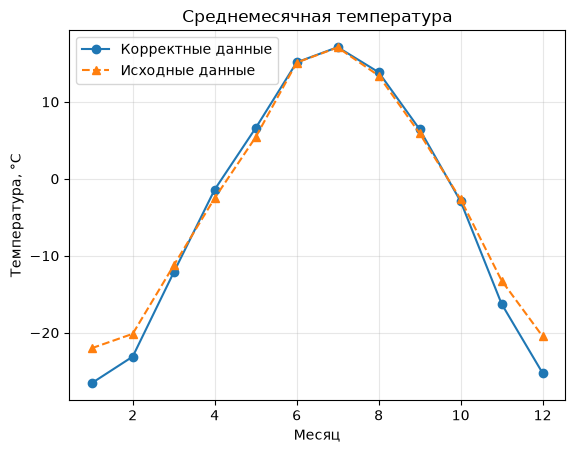

In [111]:
temp_by_month_ref = ds_temp_common_renamed.CorTmp.groupby('Time.month').mean().mean(dim=['Lat', 'Lon'])
temp_by_month_iki = ds_iki_temp_common.T_mean.groupby('Time.month').mean().mean(dim=['Lat', 'Lon'])

metrics_temp = compute_metrics(temp_by_month_ref, temp_by_month_iki)
print(metrics_temp)

plt.figure()
plt.plot(range(1, 13), temp_by_month_ref.values, label='Корректные данные', marker='o')
plt.plot(range(1, 13), temp_by_month_iki.values, label='Исходные данные', marker='^', linestyle='--')
plt.xlabel('Месяц')
plt.ylabel('Температура, °C')
plt.title('Среднемесячная температура')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Обе кривые демонстрируют выраженный годовой цикл с минимумом в зимние месяцы и максимумом в летние.
Наблюдается систематическое отклонение исходных данных от эталона: среднее смещение (Bias) составляет -1.10°C, что указывает на то, что исходные данные в среднем теплее эталонных. Средняя абсолютная ошибка (MAE) равна 1.65°C, среднеквадратичная ошибка (RMSE) 2.34°C.

{'Bias': array(-1.09532849), 'MAE': array(1.71928703), 'RMSE': array(2.46530497), 'Корреляция': array(0.99566578)}


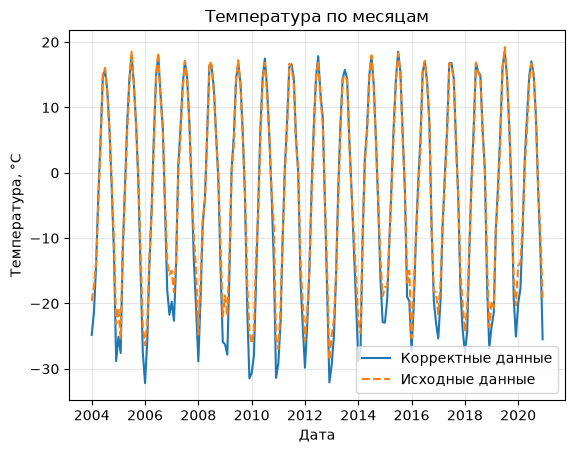

In [112]:
temp_timeseries_ref = ds_temp_common_renamed.CorTmp.mean(dim=['Lat', 'Lon'])
temp_timeseries_iki = ds_iki_temp_common.T_mean.mean(dim=['Lat', 'Lon'])

metrics_temp = compute_metrics(temp_timeseries_ref, temp_timeseries_iki)
print(metrics_temp)

plt.figure()
plt.plot(ds_temp_common_renamed.Time.values, temp_timeseries_ref.values, label='Корректные данные')
plt.plot(ds_iki_temp_common.Time.values, temp_timeseries_iki.values, label='Исходные данные', linestyle='--')
plt.xlabel('Дата')
plt.ylabel('Температура, °C')
plt.title('Температура по месяцам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Осадки**

In [113]:
common_start_p = "2004-01-01"
common_end_p = "2019-12-01"  # осадки корректного набора заканчиваются в 2019, не в 2020

ds_precip_common = ds_precip_final.sel(Time=slice(common_start_p, common_end_p))
ds_iki_precip_common = ds_iki_interp.sel(Time=slice(common_start_p, common_end_p))

ds_precip_common = ds_precip_common.sel(
    Lat=slice(64.0, 51.5),
    Lon=slice(95.5, 119.25)
)

print(ds_precip_common.Lat.values[:5], ds_iki_precip_common.Lat.values[:5])
print(ds_precip_common.Lon.values[:5], ds_iki_precip_common.Lon.values[:5])

[64.   63.75 63.5  63.25 63.  ] [64.   63.75 63.5  63.25 63.  ]
[95.5  95.75 96.   96.25 96.5 ] [95.5  95.75 96.   96.25 96.5 ]


{'Bias': array(-29.96789087), 'MAE': array(29.96789087), 'RMSE': array(33.90812263), 'Корреляция': array(0.73131355)}


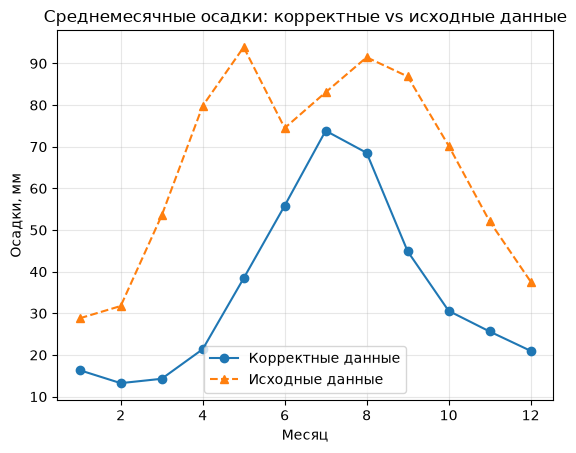

In [114]:
precip_by_month_ref = ds_precip_common.MonTPrecCor.groupby('Time.month').mean().mean(dim=['Lat', 'Lon'])
precip_by_month_iki = ds_iki_precip_common.APCP.groupby('Time.month').mean().mean(dim=['Lat', 'Lon'])

metrics_precip = compute_metrics(precip_by_month_ref, precip_by_month_iki)
print(metrics_precip)

plt.figure()
plt.plot(range(1, 13), precip_by_month_ref.values, label='Корректные данные', marker='o')
plt.plot(range(1, 13), precip_by_month_iki.values, label='Исходные данные', marker='^', linestyle='--')
plt.xlabel('Месяц')
plt.ylabel('Осадки, мм')
plt.title('Среднемесячные осадки: корректные vs исходные данные')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Исходные данные систематически завышают месячную сумму осадков во все месяцы года, особенно летом (май–август), где разница достигает 20–25 мм. Корреляция между источниками составила 0.731, Bias −29.97 мм, RMSE 33.91 мм.

{'Bias': array(-29.96789087), 'MAE': array(30.26987766), 'RMSE': array(40.14280778), 'Корреляция': array(0.61096461)}


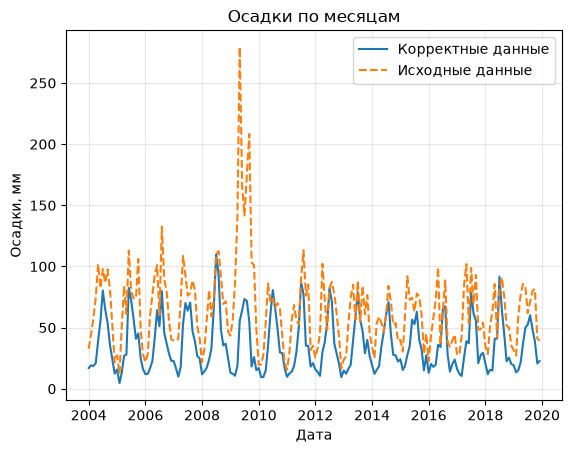

In [115]:
precip_timeseries_ref = ds_precip_common.MonTPrecCor.mean(dim=['Lat', 'Lon'])
precip_timeseries_iki = ds_iki_precip_common.APCP.mean(dim=['Lat', 'Lon'])

metrics_precip_ts = compute_metrics(precip_timeseries_ref, precip_timeseries_iki)
print(metrics_precip_ts)

plt.figure()
plt.plot(ds_precip_common.Time.values, precip_timeseries_ref.values, label='Корректные данные')
plt.plot(ds_iki_precip_common.Time.values, precip_timeseries_iki.values, label='Исходные данные', linestyle='--')
plt.xlabel('Дата')
plt.ylabel('Осадки, мм')
plt.title('Осадки по месяцам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

На всём периоде наблюдений исходные данные также стабильно превышают эталонные, а в 2009 году заметен экстремальный выброс (около 280 мм за месяц), выделяющийся на фоне остальных лет. Корреляция на полном ряде составила 0.611, RMSE 40.14 мм.

# Задача 2: Продолжение ряда на корректировочных коэффициентах (ERA5)

Скорректированные эталонные данные (CTSS/CRSS) заканчиваются раньше, чем требуется для сопоставления с пожарными событиями (2004–2024) и расчёта индекса засушливости Педя (которому нужен "период разгона" — несколько лет истории для построения базовой нормы). Поэтому ряд, скорректированный на эталон в Задаче 1, продлевается в двух направлениях с помощью реанализа ERA5:

1. **Вперёд, на 2025 год** — эталонные данные CTSS/CRSS отсутствуют, поэтому используется ERA5, скорректированный на уже исправленный ряд IKI (нахлёст 2018–2024).
2. **Назад, на 2000–2003 годы** — для формирования "периода разгона" индекса Педя, также с помощью ERA5, скорректированного на нахлёсте 2004–2005.

В обоих случаях методика одна и та же: на периоде пересечения источников вычисляется помесячный корректировочный коэффициент (аддитивный bias для температуры, мультипликативный коэффициент для осадков) для каждой точки сетки 0.25°, после чего он применяется к продлевающему периоду ERA5.

### 1. Коррекция IKI на эталон и продление вперёд (ERA5, 2025)

In [2]:
PATH_TMP_CORR = "data/raw/CTSS_1979-2020.nc"
PATH_PRC_CORR = "data/raw/CRSS_1979-2019.nc"
PATH_IKI      = "iki_inter025.nc"
PATH_ERA5_TMP = "data/raw/data_stream-moda_stepType-avgua.nc"
PATH_ERA5_PRC = "data/raw/data_stream-moda_stepType-avgad.nc"
OUT           = "iki_2004-2025.nc"

Загружаем скорректированный на сетке 0.25° ряд IKI (результат Задачи 1).

In [3]:
# 1. IKI
ds_iki     = xr.open_dataset(PATH_IKI)
iki_years  = ds_iki["Time"].dt.year.values
iki_months = ds_iki["Time"].dt.month.values
iki_lat    = ds_iki["Lat"].values
iki_lon    = ds_iki["Lon"].values
iki_t      = ds_iki["T_mean"].values
iki_apcp   = ds_iki["APCP"].values


Эталонная температура (CTSS) — нужна только для расчёта коэффициентов коррекции, обрезаем по границам области IKI.

In [4]:
# 2. CTSS — только для коэффициентов
ds_ct = xr.open_dataset(PATH_TMP_CORR)
ds_ct = ds_ct.assign_coords(
    Lat=("nLat", ds_ct["Lat"].values),
    Lon=("nLon", ds_ct["Lon"].values)
).swap_dims({"nLat": "Lat", "nLon": "Lon"})
time_vals = ds_ct["Time"].values
ct_years  = np.floor(time_vals).astype(int)
ct_months = np.round((time_vals - ct_years) * 100).astype(int)
ct_tmp    = ds_ct["CorTmp"].values
ct_lat    = ds_ct["Lat"].values
ct_lon    = ds_ct["Lon"].values

lat_m = (ct_lat >= iki_lat.min()-0.01) & (ct_lat <= iki_lat.max()+0.01)
lon_m = (ct_lon >= iki_lon.min()-0.01) & (ct_lon <= iki_lon.max()+0.01)
ct_tmp = ct_tmp[:, lat_m, :][:, :, lon_m]


Эталонные осадки (CRSS) — аналогично, только для коэффициентов.

In [5]:
# 3. CRSS — только для коэффициентов
ds_cr      = xr.open_dataset(PATH_PRC_CORR).rename({"Y": "Year", "Mon": "Month"})
cr_years_u = ds_cr["Year"].values.astype(int)
cr_prc     = ds_cr["MonTPrecCor"].values
cr_lat     = ds_cr["Lat"].values
cr_lon     = ds_cr["Lon"].values

lat_mc = (cr_lat >= iki_lat.min()-0.01) & (cr_lat <= iki_lat.max()+0.01)
lon_mc = (cr_lon >= iki_lon.min()-0.01) & (cr_lon <= iki_lon.max()+0.01)
cr_prc = cr_prc[:, :, lat_mc, :][:, :, :, lon_mc]


ERA5 (t2m — температура, tp — осадки), приводим к тем же именам координат и обрезаем по области IKI. Осадки ERA5 хранятся как среднесуточная интенсивность (м/сутки), переводим в сумму за месяц в мм.

In [6]:
# 4. ERA5
ds_et     = xr.open_dataset(PATH_ERA5_TMP)
era_t     = (ds_et["t2m"] - 273.15).rename({"latitude": "Lat", "longitude": "Lon"})
era_yt    = era_t["valid_time"].dt.year.values
era_mt    = era_t["valid_time"].dt.month.values
era_lat   = era_t["Lat"].values
era_lon   = era_t["Lon"].values

lat_me = (era_lat >= iki_lat.min()-0.01) & (era_lat <= iki_lat.max()+0.01)
lon_me = (era_lon >= iki_lon.min()-0.01) & (era_lon <= iki_lon.max()+0.01)
era_t_v   = era_t.values[:, lat_me, :][:, :, lon_me]

ds_ep     = xr.open_dataset(PATH_ERA5_PRC)
tp        = ds_ep["tp"].rename({"latitude": "Lat", "longitude": "Lon"})
era_yp    = tp["valid_time"].dt.year.values
era_mp    = tp["valid_time"].dt.month.values
days      = np.array([pd.Timestamp(y,m,1).days_in_month for y,m in zip(era_yp, era_mp)])
era_p_v   = tp.values[:, lat_me, :][:, :, lon_me] * 1000 * days[:, None, None]


**Коррекция IKI на эталон**

Для каждого месяца (1–12) и каждой точки сетки на периоде пересечения IKI и эталона:
- **температура** — аддитивный `bias[month, lat, lon]` = среднее по годам (CTSS − IKI);
- **осадки** — мультипликативный `coef[month, lat, lon]` = среднее CRSS / среднее IKI (только там, где IKI > 0.1 мм, иначе коэффициент = 1).

In [7]:
# 5. КОРРЕКЦИЯ IKI НА ЭТАЛОН

# Температура: аддитивный bias[month, lat, lon]
bias_t = np.zeros((12, len(iki_lat), len(iki_lon)))
for m in range(1, 13):
    diffs = []
    for y in sorted(set(iki_years) & set(ct_years) & set(range(2004, 2021))):
        ii = np.where((iki_years==y) & (iki_months==m))[0]
        ic = np.where((ct_years==y)  & (ct_months==m))[0]
        if len(ii)==1 and len(ic)==1:
            diffs.append(ct_tmp[ic[0]] - iki_t[ii[0]])
    if diffs:
        bias_t[m-1] = np.nanmean(diffs, axis=0)

iki_t_corr = iki_t.copy()
for i, m in enumerate(iki_months):
    iki_t_corr[i] += bias_t[m-1]
print(f"  Bias T: mean={bias_t.mean():.3f}°C")

# Осадки: мультипликативный coef[month, lat, lon]
coef_p = np.ones((12, len(iki_lat), len(iki_lon)))
for m in range(1, 13):
    iv, cv = [], []
    for y in sorted(set(iki_years) & set(cr_years_u) & set(range(2004, 2020))):
        ii  = np.where((iki_years==y) & (iki_months==m))[0]
        icy = np.where(cr_years_u==y)[0]
        if len(ii)==1 and len(icy)==1:
            iv.append(iki_apcp[ii[0]])
            cv.append(cr_prc[icy[0], m-1])
    if iv:
        im = np.nanmean(iv, axis=0)
        cm = np.nanmean(cv, axis=0)
        coef_p[m-1] = np.where(im > 0.1, cm / im, 1.0)

iki_apcp_corr = iki_apcp.copy()
for i, m in enumerate(iki_months):
    iki_apcp_corr[i] *= coef_p[m-1]
print(f"  Coef P: mean={coef_p.mean():.3f}")


  Bias T: mean=nan°C
  Coef P: mean=0.835


C:\Users\tungu\AppData\Local\Temp\ipykernel_6024\3612504999.py:13: RuntimeWarning: Mean of empty slice
  bias_t[m-1] = np.nanmean(diffs, axis=0)
C:\Users\tungu\AppData\Local\Temp\ipykernel_6024\3612504999.py:31: RuntimeWarning: Mean of empty slice
  im = np.nanmean(iv, axis=0)


#### Коррекция ERA5 на скорректированный IKI и продление на 2025 год

Та же схема коэффициентов, но теперь эталоном выступает уже скорректированный IKI, а корректируется ERA5, на нахлёсте 2018–2024. Полученные коэффициенты применяются к ERA5 за 2025 год, для которого скорректированного IKI ещё нет.

In [10]:
# 6. КОРРЕКЦИЯ ERA5 НА СКОРР. IKI

# Температура
bias_era_t = np.zeros((12, len(iki_lat), len(iki_lon)))
for m in range(1, 13):
    diffs = []
    for y in sorted(set(era_yt) & set(iki_years) & set(range(2018, 2025))):
        ie = np.where((era_yt==y) & (era_mt==m))[0]
        ii = np.where((iki_years==y) & (iki_months==m))[0]
        if len(ie)==1 and len(ii)==1:
            diffs.append(iki_t_corr[ii[0]] - era_t_v[ie[0]])
    if diffs:
        bias_era_t[m-1] = np.nanmean(diffs, axis=0)
print(f"  Bias ERA5 T: mean={bias_era_t.mean():.3f}°C")

# Осадки
coef_era_p = np.ones((12, len(iki_lat), len(iki_lon)))
for m in range(1, 13):
    ev, iv = [], []
    for y in sorted(set(era_yp) & set(iki_years) & set(range(2018, 2025))):
        ie = np.where((era_yp==y) & (era_mp==m))[0]
        ii = np.where((iki_years==y) & (iki_months==m))[0]
        if len(ie)==1 and len(ii)==1:
            ev.append(era_p_v[ie[0]])
            iv.append(iki_apcp_corr[ii[0]])
    if ev:
        em = np.nanmean(ev, axis=0)
        im = np.nanmean(iv, axis=0)
        coef_era_p[m-1] = np.where(em > 0.1, im / em, 1.0)
print(f"  Coef ERA5 P: mean={coef_era_p.mean():.3f}")

# Применяем к ERA5 2025
mask_2025_t = (era_yt == 2025)
mask_2025_p = (era_yp == 2025)
era_t_2025  = era_t_v[mask_2025_t].copy()
era_p_2025  = era_p_v[mask_2025_p].copy()
mon_2025_t  = era_mt[mask_2025_t]
mon_2025_p  = era_mp[mask_2025_p]

for i, m in enumerate(mon_2025_t):
    era_t_2025[i] += bias_era_t[m-1]
for i, m in enumerate(mon_2025_p):
    era_p_2025[i] *= coef_era_p[m-1]
print(f"  ERA5 2025: {len(mon_2025_t)} мес. температуры, {len(mon_2025_p)} мес. осадков")


  Bias ERA5 T: mean=nan°C
  Coef ERA5 P: mean=nan
  ERA5 2025: 12 мес. температуры, 12 мес. осадков


C:\Users\tungu\AppData\Local\Temp\ipykernel_6024\436685873.py:13: RuntimeWarning: Mean of empty slice
  bias_era_t[m-1] = np.nanmean(diffs, axis=0)
C:\Users\tungu\AppData\Local\Temp\ipykernel_6024\436685873.py:28: RuntimeWarning: Mean of empty slice
  im = np.nanmean(iv, axis=0)


Собираем финальный файл (2004–2025) в том же формате, что и IKI: скорректированные `T_mean`/`APCP` на сетке 0.25°, объединённые по времени и отсортированные.

In [11]:
# 7. СБОРКА — формат как у IKI

# Объединяем временные ряды
t_all    = np.concatenate([iki_t_corr, era_t_2025], axis=0)
p_all    = np.concatenate([iki_apcp_corr, era_p_2025], axis=0)
years_all  = np.concatenate([iki_years,  np.full(len(mon_2025_t), 2025)])
months_all = np.concatenate([iki_months, mon_2025_t])

# Сортируем по времени
time_all = pd.to_datetime([f"{y}-{m:02d}-01" for y,m in zip(years_all, months_all)])
order    = np.argsort(time_all)
time_all  = time_all[order]
t_all     = t_all[order]
p_all     = p_all[order]

ds_out = xr.Dataset(
    {
        "T_mean": (["Time", "Lat", "Lon"], t_all,   {"long_name": "Mean temperature", "units": "°C"}),
        "APCP":   (["Time", "Lat", "Lon"], p_all,   {"long_name": "Monthly precipitation", "units": "mm"}),
    },
    coords={
        "Time": time_all.values,
        "Lat":  iki_lat,
        "Lon":  iki_lon,
    }
)
ds_out.attrs["description"] = (
    "IKI reanalysis 2004-2024 corrected to CTSS/CRSS reference, "
    "extended to 2025 via ERA5 corrected to IKI"
)

ds_out.to_netcdf(OUT)
print(f"\nГотово: {OUT}")
print(f"  Time: {str(time_all[0])[:7]} .. {str(time_all[-1])[:7]} | шагов: {len(time_all)}")
print(f"  T_mean: min={t_all.min():.2f}, max={t_all.max():.2f} °C")
print(f"  APCP:   min={p_all.min():.2f}, max={p_all.max():.2f} мм")



Готово: iki_2004-2025.nc
  Time: 2004-01 .. 2025-12 | шагов: 264
  T_mean: min=nan, max=nan °C
  APCP:   min=nan, max=nan мм


### 2. Продление ряда назад (ERA5, 2000–2003)

Для расчёта индекса Педя на всём периоде наблюдений (с 2004 года) нужен "период разгона" — несколько предыдущих лет для построения расширяющейся базовой нормы (см. Задачу 3). Поэтому продлённый вперёд ряд (`iki_2004-2025.nc`) дополнительно продлевается назад, на 2000–2003 годы, тем же способом — через ERA5, скорректированный на нахлёсте 2004–2005 годов.

In [12]:
PATH_IKI      = "iki_2004-2025.nc"
PATH_ERA5_TMP = "data/raw/data_stream-moda_stepType-avgua_2000.nc"
PATH_ERA5_PRC = "data/raw/data_stream-moda_stepType-avgad_2000.nc"
OUT           = "iki_2000-2025.nc"


In [13]:
# 1. ЗАГРУЗКА IKI (2004-2025, уже скорректирован)
ds_iki = xr.open_dataset(PATH_IKI)
iki_times  = pd.to_datetime(ds_iki["Time"].values)
iki_years  = iki_times.year.values
iki_months = iki_times.month.values
iki_lat    = ds_iki["Lat"].values
iki_lon    = ds_iki["Lon"].values
iki_t      = ds_iki["T_mean"].values
iki_p      = ds_iki["APCP"].values


Дополнительный файл ERA5 за 2000–2005 годы (для продления назад нужны только 2000–2003, 2004–2005 уже покрыты IKI и используются для расчёта коэффициентов).

In [14]:
# 2. ЗАГРУЗКА ERA5 2000-2005
ds_et = xr.open_dataset(PATH_ERA5_TMP)
era_t = (ds_et["t2m"] - 273.15).rename({"latitude": "Lat", "longitude": "Lon"})
era_yt = era_t["valid_time"].dt.year.values
era_mt = era_t["valid_time"].dt.month.values
era_lat = era_t["Lat"].values
era_lon = era_t["Lon"].values

lat_m = (era_lat >= iki_lat.min()-0.01) & (era_lat <= iki_lat.max()+0.01)
lon_m = (era_lon >= iki_lon.min()-0.01) & (era_lon <= iki_lon.max()+0.01)
era_t_v = era_t.values[:, lat_m, :][:, :, lon_m]
era_lat = era_lat[lat_m]
era_lon = era_lon[lon_m]

print(f"  ERA5 t2m сетка: lat={era_lat[0]}..{era_lat[-1]}, lon={era_lon[0]}..{era_lon[-1]}")
print(f"  Совпадает с IKI: lat={np.allclose(era_lat, iki_lat)}, lon={np.allclose(era_lon, iki_lon)}")

ds_ep = xr.open_dataset(PATH_ERA5_PRC)
tp    = ds_ep["tp"].rename({"latitude": "Lat", "longitude": "Lon"})
era_yp = tp["valid_time"].dt.year.values
era_mp = tp["valid_time"].dt.month.values
days   = np.array([pd.Timestamp(y,m,1).days_in_month for y,m in zip(era_yp, era_mp)])
era_p_v = tp.values[:, lat_m, :][:, :, lon_m] * 1000 * days[:, None, None]


  ERA5 t2m сетка: lat=64.0..51.5, lon=95.5..119.25
  Совпадает с IKI: lat=True, lon=True


Коэффициенты коррекции ERA5 -> IKI считаются на нахлёсте 2004–2005 годов (единственный доступный для этой пары источников).

In [15]:
# 3. КОРРЕКЦИЯ ERA5 НА IKI (нахлёст 2004-2005)

overlap_years = sorted(set(era_yt) & set(iki_years) & set(range(2004, 2006)))
print(f"  Нахлёст: {overlap_years}")

# Температура: аддитивный bias по месяцу
bias_t = np.zeros((12, len(iki_lat), len(iki_lon)))
for m in range(1, 13):
    diffs = []
    for y in overlap_years:
        ie = np.where((era_yt==y) & (era_mt==m))[0]
        ii = np.where((iki_years==y) & (iki_months==m))[0]
        if len(ie)==1 and len(ii)==1:
            diffs.append(iki_t[ii[0]] - era_t_v[ie[0]])
    if diffs:
        bias_t[m-1] = np.nanmean(diffs, axis=0)
print(f"  Bias T: mean={np.nanmean(bias_t):.3f}°C")

# Осадки: мультипликативный коэффициент по месяцу
coef_p = np.ones((12, len(iki_lat), len(iki_lon)))
for m in range(1, 13):
    ev, iv = [], []
    for y in overlap_years:
        ie = np.where((era_yp==y) & (era_mp==m))[0]
        ii = np.where((iki_years==y) & (iki_months==m))[0]
        if len(ie)==1 and len(ii)==1:
            ev.append(era_p_v[ie[0]])
            iv.append(iki_p[ii[0]])
    if ev:
        em = np.nanmean(ev, axis=0)
        im = np.nanmean(iv, axis=0)
        coef_p[m-1] = np.where(em > 0.1, im / em, 1.0)
print(f"  Coef P: mean={np.nanmean(coef_p):.3f}")

# Применяем к ERA5 2000-2003 (2004-2005 уже есть в IKI)
mask_new_t = era_yt <= 2003
mask_new_p = era_yp <= 2003

era_t_new  = era_t_v[mask_new_t].copy()
era_p_new  = era_p_v[mask_new_p].copy()
yrs_new_t  = era_yt[mask_new_t]
mon_new_t  = era_mt[mask_new_t]
yrs_new_p  = era_yp[mask_new_p]
mon_new_p  = era_mp[mask_new_p]

for i, m in enumerate(mon_new_t):
    era_t_new[i] += bias_t[m-1]
for i, m in enumerate(mon_new_p):
    era_p_new[i] *= coef_p[m-1]

print(f"  ERA5 продление: {len(yrs_new_t)} мес. температуры ({sorted(set(yrs_new_t))})")


  Нахлёст: [2004, 2005]
  Bias T: mean=0.099°C
  Coef P: mean=0.763
  ERA5 продление: 48 мес. температуры ([np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003)])


C:\Users\tungu\AppData\Local\Temp\ipykernel_6024\4230180311.py:16: RuntimeWarning: Mean of empty slice
  bias_t[m-1] = np.nanmean(diffs, axis=0)
C:\Users\tungu\AppData\Local\Temp\ipykernel_6024\4230180311.py:31: RuntimeWarning: Mean of empty slice
  im = np.nanmean(iv, axis=0)


Собираем итоговый файл **iki_2000-2025.nc** — скорректированный ряд, покрывающий весь период 2000–2025 годов.

In [16]:
# 4. СБОРКА ИТОГОВОГО ФАЙЛА

t_all = np.concatenate([era_t_new, iki_t], axis=0)
p_all = np.concatenate([era_p_new, iki_p], axis=0)

years_all  = np.concatenate([yrs_new_t,  iki_years])
months_all = np.concatenate([mon_new_t,  iki_months])

time_all = pd.to_datetime([f"{y}-{m:02d}-01" for y,m in zip(years_all, months_all)])
order = np.argsort(time_all)
time_all = time_all[order]
t_all    = t_all[order]
p_all    = p_all[order]

ds_out = xr.Dataset(
    {
        "T_mean": (["Time", "Lat", "Lon"], t_all, {"long_name": "Mean temperature", "units": "°C"}),
        "APCP":   (["Time", "Lat", "Lon"], p_all, {"long_name": "Monthly precipitation", "units": "mm"}),
    },
    coords={"Time": time_all.values, "Lat": iki_lat, "Lon": iki_lon}
)
ds_out.attrs["description"] = (
    "IKI corrected 2004-2025, extended backward to 2000-2003 via ERA5 "
    "corrected to IKI on overlap 2004-2005"
)

ds_out.to_netcdf(OUT)
print(f"\nГотово: {OUT}")
print(f"  Time: {str(time_all[0])[:7]} .. {str(time_all[-1])[:7]} | шагов: {len(time_all)}")



Готово: iki_2000-2025.nc
  Time: 2000-01 .. 2025-12 | шагов: 312


### 3. Проверка результата — графики

Ниже — контрольные графики: сравнение всех источников (эталон / IKI сырые / ERA5 сырые / итоговый скорректированный ряд) и нахлёстов между ними. Итоговый ряд теперь охватывает **2000–2025**, поэтому графики финального результата обновлены по сравнению с исходной версией скрипта (там использовался только период 2004–2025): добавлена подсветка обоих продлённых через ERA5 участков — 2000–2003 (продление назад) и 2025 (продление вперёд). Графики нахлёстов источников (1–4) не менялись, так как они строятся по исходным периодам самих источников и не зависят от продления.

In [17]:
PATH_IKI_ORIG = "iki_inter025.nc"
PATH_CTSS     = "data/raw/CTSS_1979-2020.nc"
PATH_CRSS     = "data/raw/CRSS_1979-2019.nc"
PATH_ERA5_TMP = "data/raw/data_stream-moda_stepType-avgua.nc"
PATH_ERA5_PRC = "data/raw/data_stream-moda_stepType-avgad.nc"
PATH_RESULT   = "iki_2000-2025.nc"  # обновлено: теперь полный продлённый ряд, а не только 2004-2025

LAT_C, LON_C  = 52.25, 104.25  # Иркутск


def nearest_series(data, times, lat, lon):
    ilat = np.argmin(np.abs(lat - LAT_C))
    ilon = np.argmin(np.abs(lon - LON_C))
    return pd.Series(data[:, ilat, ilon], index=pd.to_datetime(times))


Загрузка всех полученных и исходных данных

In [18]:
# IKI оригинал
ds_iki    = xr.open_dataset(PATH_IKI_ORIG)
iki_times = ds_iki["Time"].values
iki_lat   = ds_iki["Lat"].values
iki_lon   = ds_iki["Lon"].values

ser_iki_t = nearest_series(ds_iki["T_mean"].values, iki_times, iki_lat, iki_lon)
ser_iki_p = nearest_series(ds_iki["APCP"].values,   iki_times, iki_lat, iki_lon)

# CTSS эталон температуры
ds_ct  = xr.open_dataset(PATH_CTSS)
ds_ct  = ds_ct.assign_coords(
    Lat=("nLat", ds_ct["Lat"].values),
    Lon=("nLon", ds_ct["Lon"].values)
).swap_dims({"nLat": "Lat", "nLon": "Lon"})
tv     = ds_ct["Time"].values
ct_y   = np.floor(tv).astype(int)
ct_m   = np.round((tv - ct_y) * 100).astype(int)
ct_times = pd.to_datetime([f"{y}-{m:02d}-01" for y,m in zip(ct_y, ct_m)])
ct_lat = ds_ct["Lat"].values
ct_lon = ds_ct["Lon"].values
lat_m  = (ct_lat >= iki_lat.min()-0.01) & (ct_lat <= iki_lat.max()+0.01)
lon_m  = (ct_lon >= iki_lon.min()-0.01) & (ct_lon <= iki_lon.max()+0.01)
ct_sub = ds_ct["CorTmp"].values[:, lat_m, :][:, :, lon_m]
ser_ct = nearest_series(ct_sub, ct_times, ct_lat[lat_m], ct_lon[lon_m])

# CRSS эталон осадков
ds_cr   = xr.open_dataset(PATH_CRSS).rename({"Y": "Year", "Mon": "Month"})
cr_y_u  = ds_cr["Year"].values.astype(int)
cr_lat  = ds_cr["Lat"].values
cr_lon  = ds_cr["Lon"].values
lat_mc  = (cr_lat >= iki_lat.min()-0.01) & (cr_lat <= iki_lat.max()+0.01)
lon_mc  = (cr_lon >= iki_lon.min()-0.01) & (cr_lon <= iki_lon.max()+0.01)
cr_sub  = ds_cr["MonTPrecCor"].values[:, :, lat_mc, :][:, :, :, lon_mc]
cr_flat = cr_sub.reshape(-1, lat_mc.sum(), lon_mc.sum())
cr_ym   = [(y, m) for y in cr_y_u for m in range(1, 13)]
cr_times = pd.to_datetime([f"{y}-{m:02d}-01" for y,m in cr_ym])
ser_cr  = nearest_series(cr_flat, cr_times, cr_lat[lat_mc], cr_lon[lon_mc])

# ERA5 температура
ds_et   = xr.open_dataset(PATH_ERA5_TMP)
era_t   = (ds_et["t2m"] - 273.15).rename({"latitude": "Lat", "longitude": "Lon"})
era_lat = era_t["Lat"].values
era_lon = era_t["Lon"].values
lat_me  = (era_lat >= iki_lat.min()-0.01) & (era_lat <= iki_lat.max()+0.01)
lon_me  = (era_lon >= iki_lon.min()-0.01) & (era_lon <= iki_lon.max()+0.01)
era_t_v = era_t.values[:, lat_me, :][:, :, lon_me]
era_t_times = era_t["valid_time"].values
ser_era_t = nearest_series(era_t_v, era_t_times, era_lat[lat_me], era_lon[lon_me])

# ERA5 осадки
ds_ep   = xr.open_dataset(PATH_ERA5_PRC)
tp      = ds_ep["tp"].rename({"latitude": "Lat", "longitude": "Lon"})
era_yp  = tp["valid_time"].dt.year.values
era_mp  = tp["valid_time"].dt.month.values
days    = np.array([pd.Timestamp(y,m,1).days_in_month for y,m in zip(era_yp, era_mp)])
era_p_v = tp.values[:, lat_me, :][:, :, lon_me] * 1000 * days[:, None, None]
ser_era_p = nearest_series(era_p_v, tp["valid_time"].values, era_lat[lat_me], era_lon[lon_me])

# Результат
ds_res  = xr.open_dataset(PATH_RESULT)
res_lat = ds_res["Lat"].values
res_lon = ds_res["Lon"].values
ser_res_t = nearest_series(ds_res["T_mean"].values, ds_res["Time"].values, res_lat, res_lon)
ser_res_p = nearest_series(ds_res["APCP"].values,   ds_res["Time"].values, res_lat, res_lon)


**График 1: температура — полный обзор.**

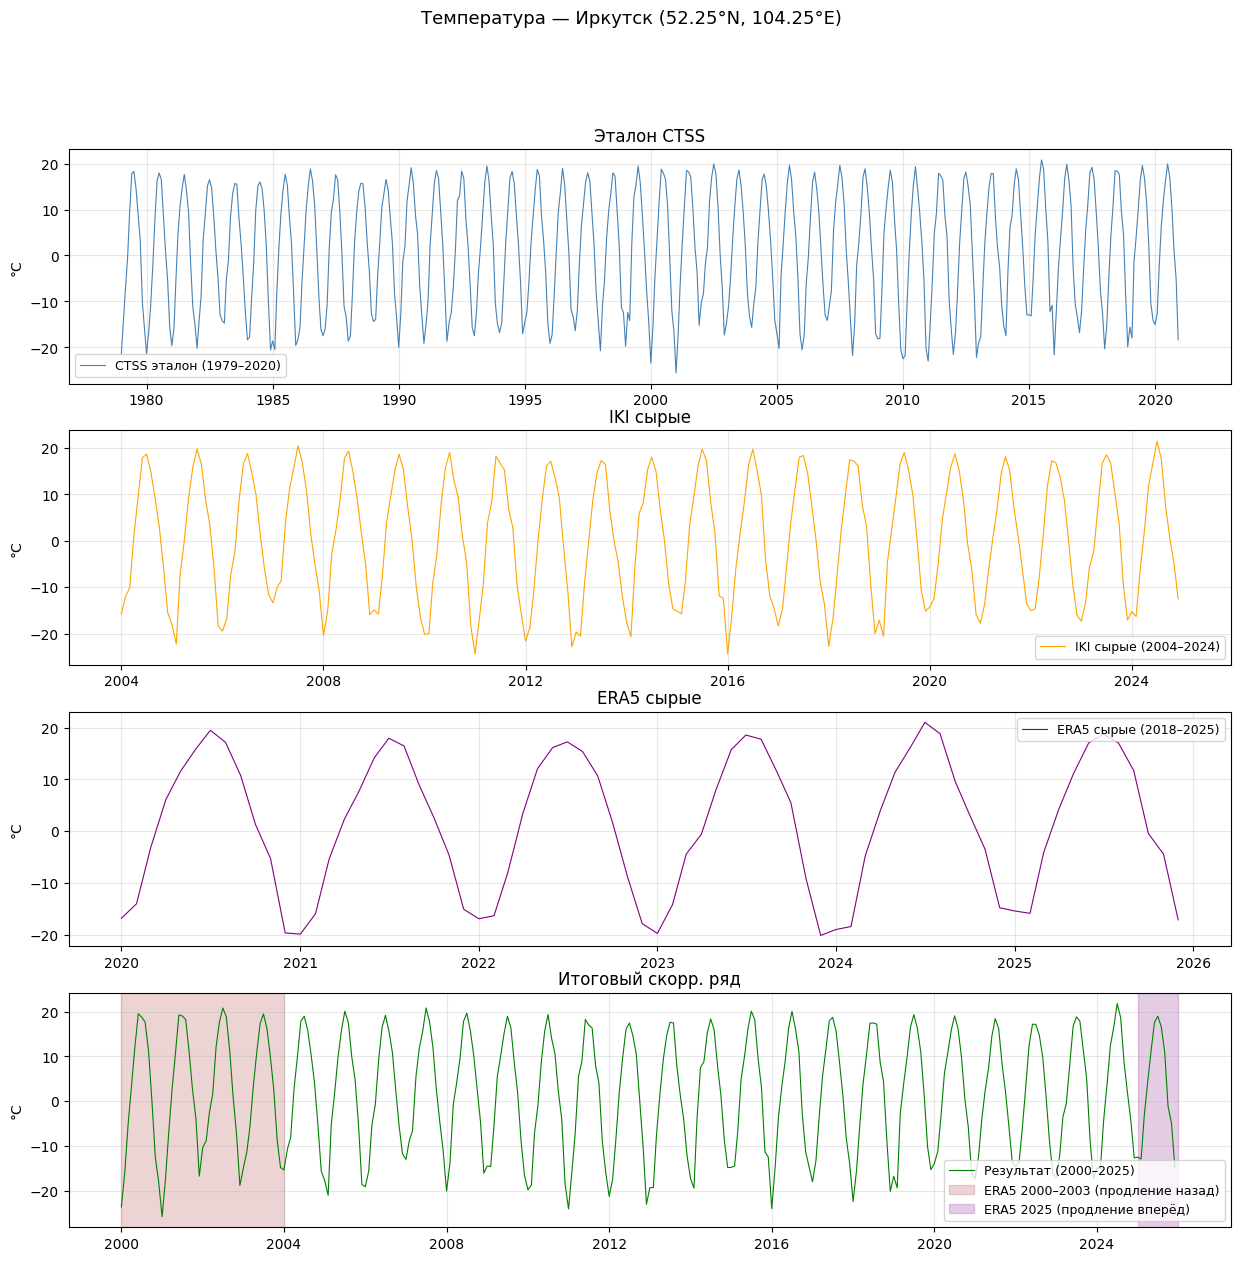

In [19]:
fig, axes = plt.subplots(4, 1, figsize=(15, 14))
fig.suptitle(f"Температура — Иркутск ({LAT_C}°N, {LON_C}°E)", fontsize=13)

axes[0].plot(ser_ct.index, ser_ct.values, color="steelblue", lw=0.8, label="CTSS эталон (1979–2020)")
axes[0].set_title("Эталон CTSS"); axes[0].set_ylabel("°C")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(ser_iki_t.index, ser_iki_t.values, color="orange", lw=0.8, label="IKI сырые (2004–2024)")
axes[1].set_title("IKI сырые"); axes[1].set_ylabel("°C")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

axes[2].plot(ser_era_t.index, ser_era_t.values, color="purple", lw=0.8, label="ERA5 сырые (2018–2025)")
axes[2].set_title("ERA5 сырые"); axes[2].set_ylabel("°C")
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

axes[3].plot(ser_res_t.index, ser_res_t.values, color="green", lw=0.8, label="Результат (2000–2025)")
axes[3].axvspan(pd.Timestamp("2000-01-01"), pd.Timestamp("2003-12-31"),
                alpha=0.2, color="brown", label="ERA5 2000–2003 (продление назад)")
axes[3].axvspan(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"),
                alpha=0.2, color="purple", label="ERA5 2025 (продление вперёд)")
axes[3].set_title("Итоговый скорр. ряд"); axes[3].set_ylabel("°C")
axes[3].legend(fontsize=9); axes[3].grid(alpha=0.3)

plt.show(fig)


**График 2: осадки — полный обзор.**

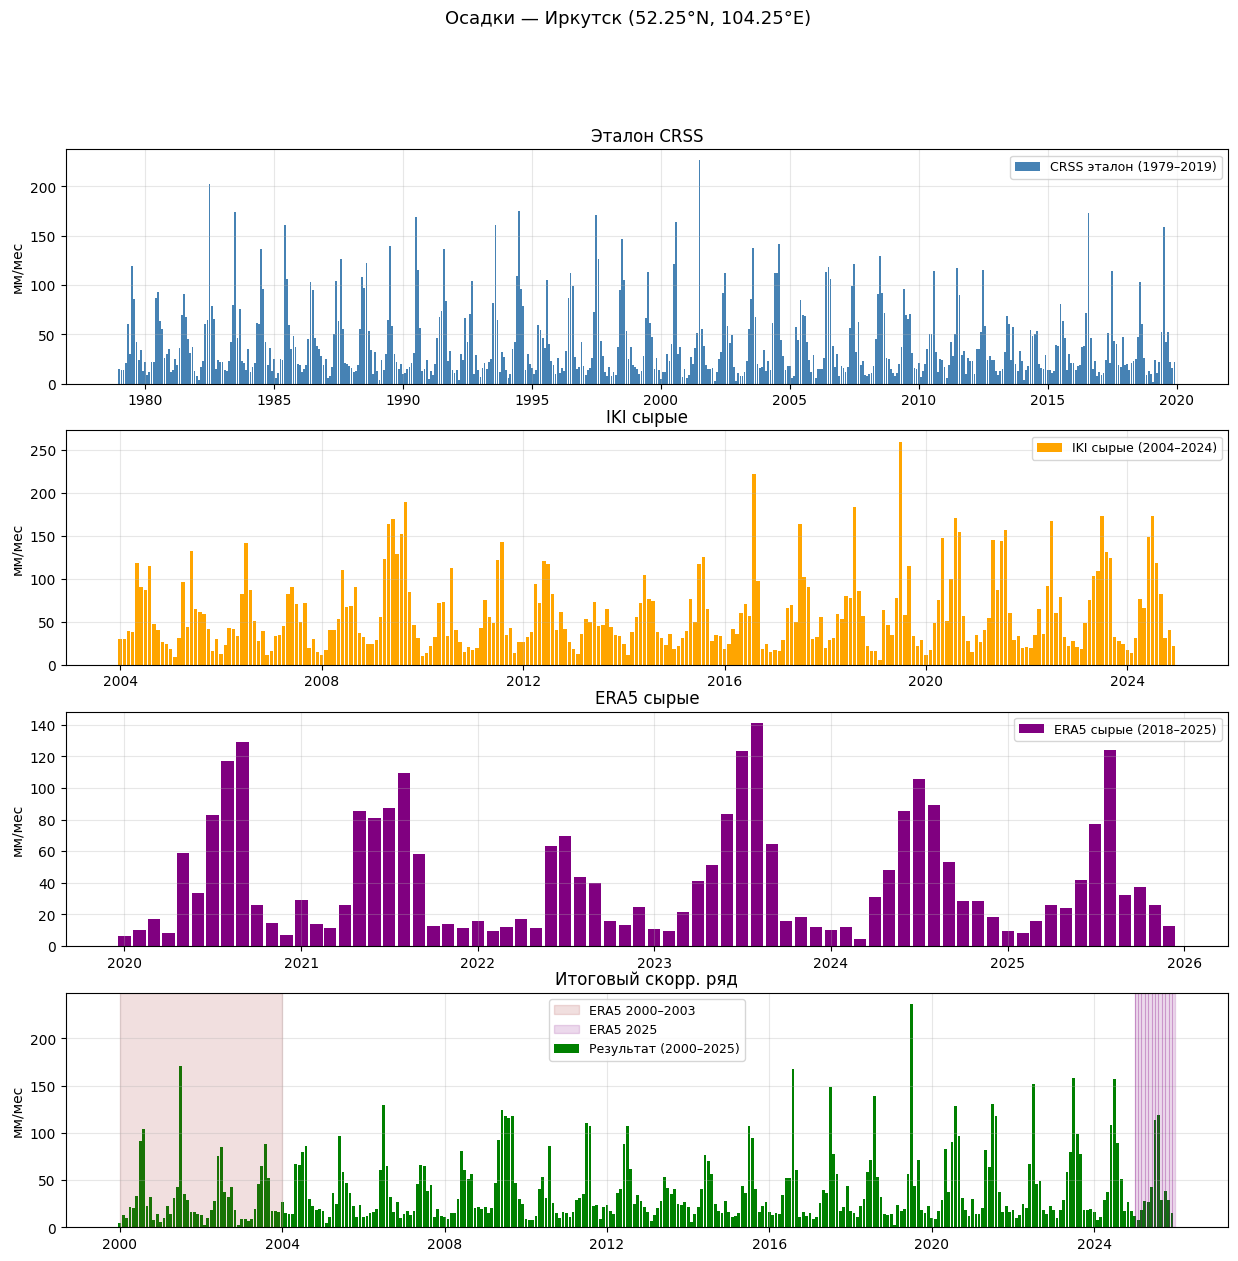

In [21]:
fig, axes = plt.subplots(4, 1, figsize=(15, 14))
fig.suptitle(f"Осадки — Иркутск ({LAT_C}°N, {LON_C}°E)", fontsize=13)

axes[0].bar(ser_cr.index, ser_cr.values, width=25, color="steelblue", label="CRSS эталон (1979–2019)")
axes[0].set_title("Эталон CRSS"); axes[0].set_ylabel("мм/мес")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].bar(ser_iki_p.index, ser_iki_p.values, width=25, color="orange", label="IKI сырые (2004–2024)")
axes[1].set_title("IKI сырые"); axes[1].set_ylabel("мм/мес")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

axes[2].bar(ser_era_p.index, ser_era_p.values, width=25, color="purple", label="ERA5 сырые (2018–2025)")
axes[2].set_title("ERA5 сырые"); axes[2].set_ylabel("мм/мес")
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

axes[3].bar(ser_res_p.index, ser_res_p.values, width=25, color="green", label="Результат (2000–2025)")
axes[3].axvspan(pd.Timestamp("2000-01-01"), pd.Timestamp("2003-12-31"),
                alpha=0.15, color="brown", label="ERA5 2000–2003")
axes[3].axvspan(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"),
                alpha=0.15, color="purple", label="ERA5 2025")
for x in pd.date_range("2025-01-01", "2025-12-01", freq="MS"):
    axes[3].axvline(x, color="purple", alpha=0.3, lw=0.8)
axes[3].set_title("Итоговый скорр. ряд"); axes[3].set_ylabel("мм/мес")
axes[3].legend(fontsize=9); axes[3].grid(alpha=0.3)

plt.show(fig)


**График 3: нахлёст IKI с эталоном.**

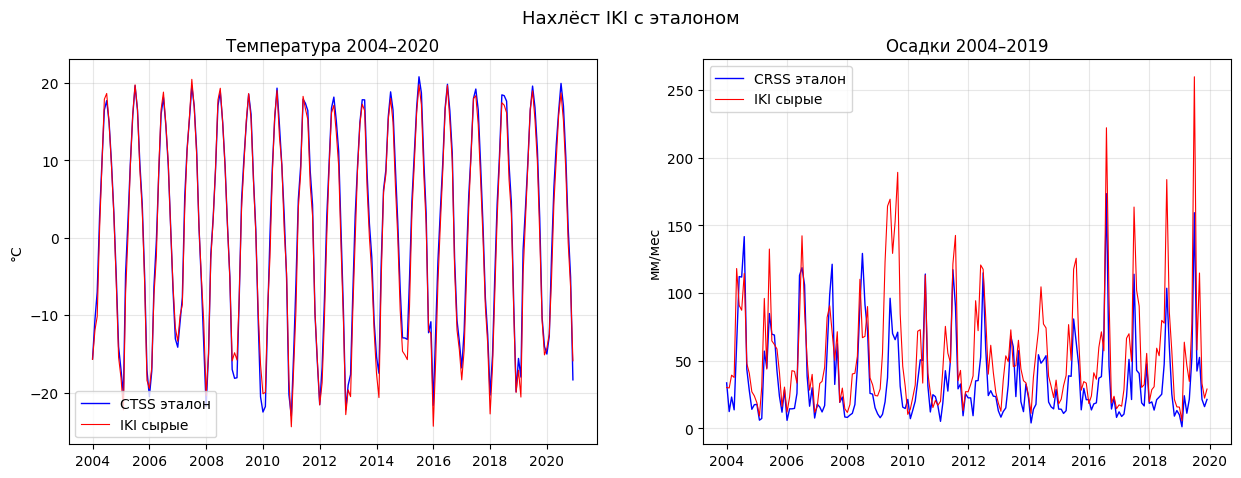

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Нахлёст IKI с эталоном", fontsize=13)

ov1 = slice("2004-01-01", "2020-12-31")
axes[0].plot(ser_ct[ov1].index,    ser_ct[ov1].values,    "b-", lw=1,   label="CTSS эталон")
axes[0].plot(ser_iki_t[ov1].index, ser_iki_t[ov1].values, "r-", lw=0.8, label="IKI сырые")
axes[0].set_title("Температура 2004–2020")
axes[0].set_ylabel("°C"); axes[0].legend(); axes[0].grid(alpha=0.3)

ov2 = slice("2004-01-01", "2019-12-31")
axes[1].plot(ser_cr[ov2].index,    ser_cr[ov2].values,    "b-", lw=1,   label="CRSS эталон")
axes[1].plot(ser_iki_p[ov2].index, ser_iki_p[ov2].values, "r-", lw=0.8, label="IKI сырые")
axes[1].set_title("Осадки 2004–2019")
axes[1].set_ylabel("мм/мес"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.show(fig)


**График 4: нахлёст ERA5 со скорректированным IKI.**

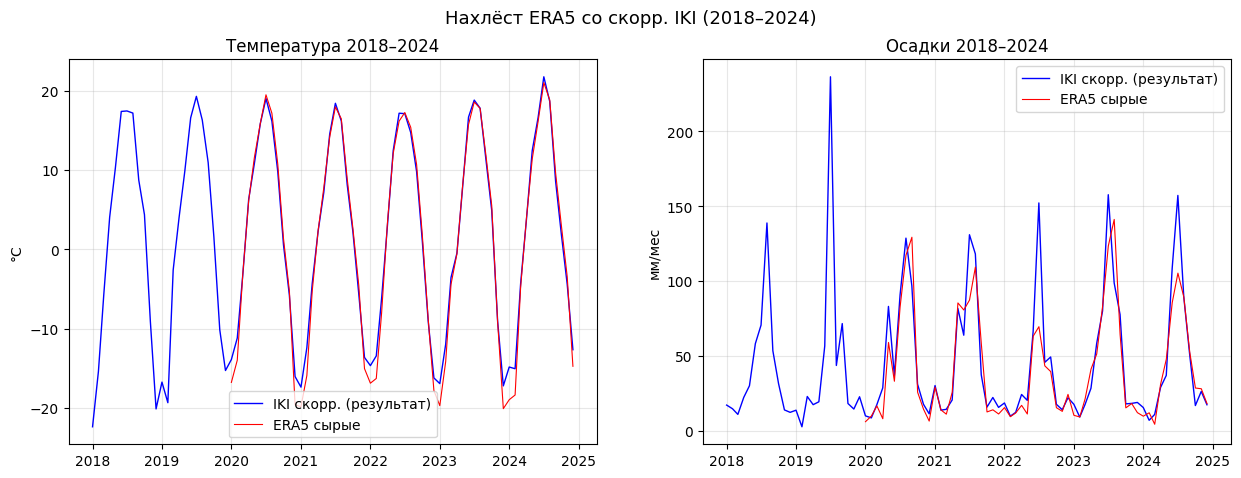

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Нахлёст ERA5 со скорр. IKI (2018–2024)", fontsize=13)

ov3 = slice("2018-01-01", "2024-12-31")
axes[0].plot(ser_res_t[ov3].index, ser_res_t[ov3].values, "b-", lw=1,   label="IKI скорр. (результат)")
axes[0].plot(ser_era_t[ov3].index, ser_era_t[ov3].values, "r-", lw=0.8, label="ERA5 сырые")
axes[0].set_title("Температура 2018–2024")
axes[0].set_ylabel("°C"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ser_res_p[ov3].index, ser_res_p[ov3].values, "b-", lw=1,   label="IKI скорр. (результат)")
axes[1].plot(ser_era_p[ov3].index, ser_era_p[ov3].values, "r-", lw=0.8, label="ERA5 сырые")
axes[1].set_title("Осадки 2018–2024")
axes[1].set_ylabel("мм/мес"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.show(fig)


**График 5: итоговый ряд целиком.**

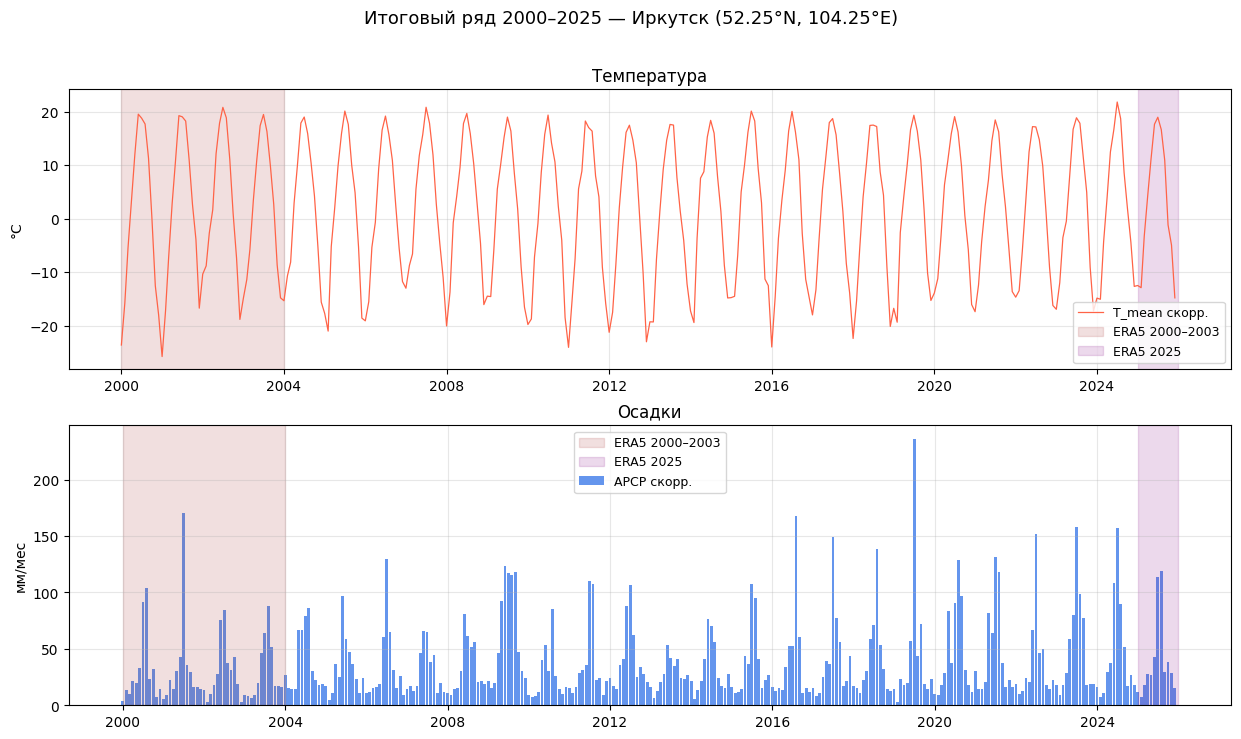

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
fig.suptitle(f"Итоговый ряд 2000–2025 — Иркутск ({LAT_C}°N, {LON_C}°E)", fontsize=13)

axes[0].plot(ser_res_t.index, ser_res_t.values, color="tomato", lw=0.9, label="T_mean скорр.")
axes[0].axvspan(pd.Timestamp("2000-01-01"), pd.Timestamp("2003-12-31"),
                alpha=0.15, color="brown", label="ERA5 2000–2003")
axes[0].axvspan(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"),
                alpha=0.15, color="purple", label="ERA5 2025")
axes[0].set_ylabel("°C"); axes[0].set_title("Температура")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].bar(ser_res_p.index, ser_res_p.values, width=25, color="cornflowerblue", label="APCP скорр.")
axes[1].axvspan(pd.Timestamp("2000-01-01"), pd.Timestamp("2003-12-31"),
                alpha=0.15, color="brown", label="ERA5 2000–2003")
axes[1].axvspan(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"),
                alpha=0.15, color="purple", label="ERA5 2025")
axes[1].set_ylabel("мм/мес"); axes[1].set_title("Осадки")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.show(fig)


# Задача 3: Расчёт индекса засушливости Педя и класса засухи

**Формула.** Индекс Педя для месяца оценивает совместное отклонение температуры и осадков от климатической нормы:

$$ S = \frac{\Delta T}{\sigma_T} - \frac{\Delta P}{\sigma_P} $$

Где:
* $S$ — индекс засушливости Педя;
* $\Delta T$ — абсолютная аномалия средней месячной температуры воздуха ($T_{факт} - T_{норм}$);
* $\Delta P$ — абсолютная аномалия месячной суммы осадков ($P_{факт} - P_{норм}$);
* $\sigma_T$ — среднее квадратическое отклонение температуры воздуха за многолетний период;
* $\sigma_P$ — среднее квадратическое отклонение количества осадков за многолетний период;
* $T_{факт}, P_{факт}$ — фактические значения температуры и осадков за исследуемый месяц;
* $T_{норм}, P_{норм}$ — климатическая норма (многолетнее среднее) для этого месяца.


**Входные данные** — скорректированный ряд `T_mean`/`APCP` на сетке 0.25° за 2000–2025 годы (результат Задачи 2).

**Норма — расширяющееся окно (expanding window).** Для каждого месяца норма считается по всем годам, предшествующим текущему (минимум 2 года истории), а не по фиксированному климатическому периоду. Из-за этого первые годы ряда (2000–2003) — это как раз "период разгона", необходимый для накопления истории; сам индекс сохраняется только начиная с 2004 года.

**Обработка краевых случаев:**
- если данных T и P за месяц нет — индексу присваивается NaN;
- если σ_T > 0, а σ_P = 0 (осадки в точке за все предыдущие годы не менялись) — считать по формуле напрямую нельзя (деление на 0), такие точки заменяются средним по соседям 3×3 (без NaN);
- итоговое значение обрезается по диапазону [-4, 4].

### 1. Функция расчёта индекса Педя

In [29]:
MIN_YEARS = 2
CLIP_MIN  = -4.0
CLIP_MAX  =  4.0

In [ ]:
def calculate_pedy(file_path, output_path):
    ds = xr.open_dataset(file_path)

    years = ds["Time"].dt.year.values
    months = ds["Time"].dt.month.values
    t_arr = ds["T_mean"].values
    p_arr = ds["APCP"].values

    pedy = np.full(t_arr.shape, np.nan, dtype=np.float32)

    start_year = int(years.min()) + 1
    end_year   = int(years.max())

    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            cur_idx = np.where((years == year) & (months == month))[0]
            if len(cur_idx) == 0:
                continue
            cur_idx = cur_idx[0]

            past_idx = np.where((years < year) & (months == month))[0]
            if len(past_idx) < MIN_YEARS:
                continue

            t_cur  = t_arr[cur_idx]
            p_cur  = p_arr[cur_idx]
            t_past = t_arr[past_idx]
            p_past = p_arr[past_idx]

            t_norm = np.nanmean(t_past, axis=0)
            t_std  = np.nanstd(t_past, axis=0, ddof=1)
            p_norm = np.nanmean(p_past, axis=0)
            p_std  = np.nanstd(p_past, axis=0, ddof=1)

            t_has_var = t_std > 0
            p_has_var = p_std > 0

            t_term = np.where(t_has_var,
                              (t_cur - t_norm) / np.where(t_has_var, t_std, 1.0),
                              0.0)
            p_term = np.where(p_has_var,
                              (p_cur - p_norm) / np.where(p_has_var, p_std, 1.0),
                              0.0)

            s_i = t_term - p_term
            s_i = np.clip(s_i, CLIP_MIN, CLIP_MAX)

            # Где исходных данных нет — NaN
            no_data = np.isnan(t_cur) & np.isnan(p_cur)
            s_i[no_data] = np.nan

            # Где p_std=0 но t_std>0 — заменяем средним соседей 3x3
            suspect = t_has_var & ~p_has_var & ~no_data

            if np.any(suspect):
                # Считаем среднее соседей игнорируя NaN
                def nanmean_neighbors(x):
                    center = x[len(x)//2]
                    neighbors = np.concatenate([x[:len(x)//2], x[len(x)//2+1:]])
                    valid = neighbors[~np.isnan(neighbors)]
                    return np.nanmean(valid) if len(valid) > 0 else center

                neighbor_mean = generic_filter(
                    s_i, nanmean_neighbors, size=3, mode='nearest'
                )
                s_i = np.where(suspect, neighbor_mean, s_i)

            pedy[cur_idx] = s_i.astype(np.float32)

    ds["pedy_index"] = (("Time", "Lat", "Lon"), pedy)
    ds["pedy_index"].attrs["description"] = (
        f"Pedy drought index, expanding rolling norm (min {MIN_YEARS} years), "
        f"clipped to [{CLIP_MIN}, {CLIP_MAX}]. "
        "Points with p_std=0 interpolated from neighbors."
    )
    ds["pedy_index"].attrs["units"] = "dimensionless"
    ds = ds.sel(Time=slice('2004', None))
    ds.to_netcdf(output_path)
    ds.close()
    print("Готово:", output_path)


Вызов функции — на входе полный продлённый ряд 2000–2025 (Задача 2), на выходе файл с индексом Педя, обрезанный до 2004 года (2000–2003 — только период разгона для нормы, самих значений индекса в выходном файле за эти годы нет).

In [ ]:
calculate_pedy("iki_2000-2025.nc", "iki_2004-2025_pedy.nc")

### 2. Визуализация индекса Педя

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
def plot_pedy_map(file_path, year, month):
    # Открываем измененный датасет с посчитанным pedy_index
    if month < 1 or month > 12:
        raise ValueError("Месяц должен быть в диапазоне от 1 до 12.")
    ds = xr.open_dataset(file_path)

    # Выбираем срез данных по указанному году и месяцу
    time_slice = ds["pedy_index"].sel(
        Time=(ds["Time"].dt.year == year) & (ds["Time"].dt.month == month)
    )

    # Если по времени нашлось несколько шагов или структура требует явного выбора первого элемента
    if time_slice.ndim > 2:
        time_slice = time_slice.isel(Time=0)

    # Создаем фигуру и объект осей с географической проекцией
    plt.figure(figsize=(12, 9))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Настраиваем отображение карты: добавляем границы, реки и озера (включая Байкал)
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=1)
    ax.add_feature(
        cfeature.LAKES, edgecolor="black", facecolor="lightblue", alpha=0.5
    )
    ax.add_feature(cfeature.RIVERS, edgecolor="blue", linewidth=0.5)

    # Отрисовываем индекс Педя
    # Используем расходящуюся цветовую схему, где:
    # Жёлтый(Positive) — засуха (высокая T, мало осадков)
    # Фиолетовый(Negative) — избыточное увлажнение (низкая T, много осадков)
    pedy_plot = time_slice.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        vmax=4,
        vmin=-4,  # Индекс Педя обычно лежит в пределах от -4 до +4
        cbar_kwargs={
            "label": "Индекс засушливости Педя (Si)",
            "orientation": "horizontal",
            "pad": 0.05,
            "shrink": 0.7,
        },
    )

    # Добавляем сетку координат (градусы)
    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    
    months = ["Январь", "Февраль", "Март", "Апрель", "Май", "Июнь", "Июль", "Август", "Сентябрь", "Октябрь", "Ноябрь", "Декабрь",]
    
    # Заголовок карты
    plt.title(
        f"Пространственное распределение индекса Педя\n{year} год, месяц: {months[month-1]}",
        fontsize=14,
        pad=20,
    )

    # Показываем карту
    plt.show()
    ds.close()


Пример вызова — 2019 год, июль.

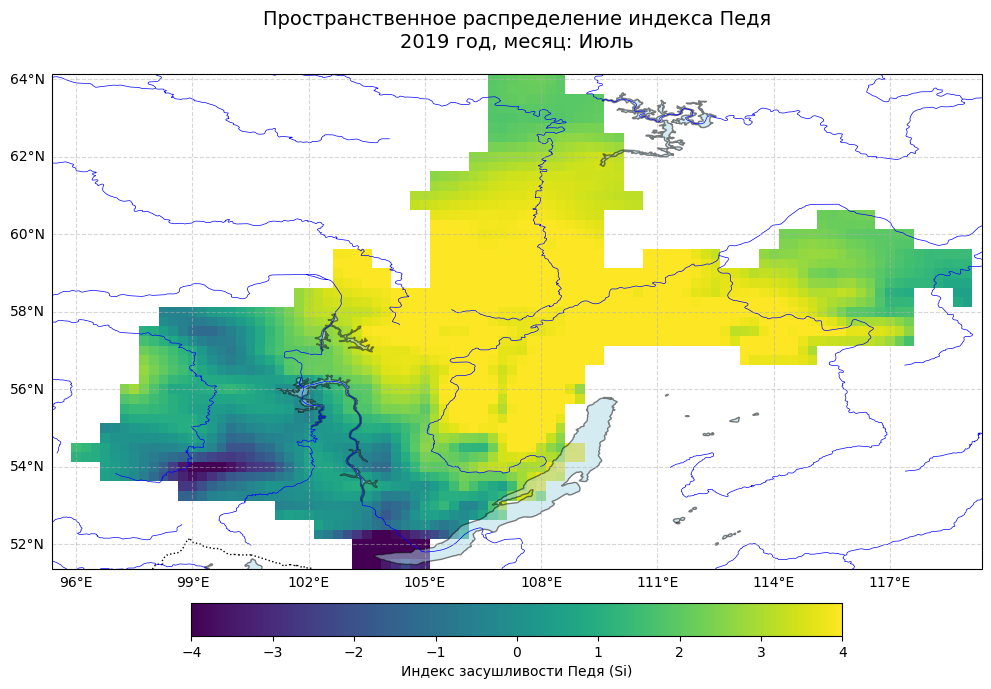

In [4]:
plot_pedy_map("iki_2004-2025_pedy.nc", 2019, 7)

Индекс засушливости Педя $S_i$ используется для оценки степени увлажнения или засушливости конкретного месяца или сезона. Его значения обычно колеблются в пределах от -4 до +4, где знак и величина показывают отклонение от нормы. Вот что означают эти показатели:
* Выше +3.0 — экстремальная (жестокая) засуха.
* От +2.0 до +3.0 — сильная засуха.
* От +1.0 до +2.0 — умеренная засуха.
* От -1.0 до +1.0 — условия, близкие к климатической норме.
* От -2.0 до -1.0 — умеренное избыточное увлажнение.
* От -3.0 до -2.0 — сильное переувлажнение.
* Ниже -3.0 — экстремальное переувлажнение.

### Индекс Педя в двух точках: «у воды» и «в тайге»

Дополнительные графики — сравнение хода индекса в двух характерных точках сетки: у берега Байкала (сглаживающее влияние водоёма) и в тайге вдали от крупных водоёмов (более континентальный, засухонеустойчивый режим).

In [7]:
ds_pedy = xr.open_dataset("iki_2004-2025_pedy.nc")

points = {
    "Байкал (Листвянка, у воды)": (51.75, 104.75),
    "Тайга (Куйтунский р-н , вдали от воды)": (58, 105),
}


**График 1** — полный временной ряд индекса Педя в обеих точках.

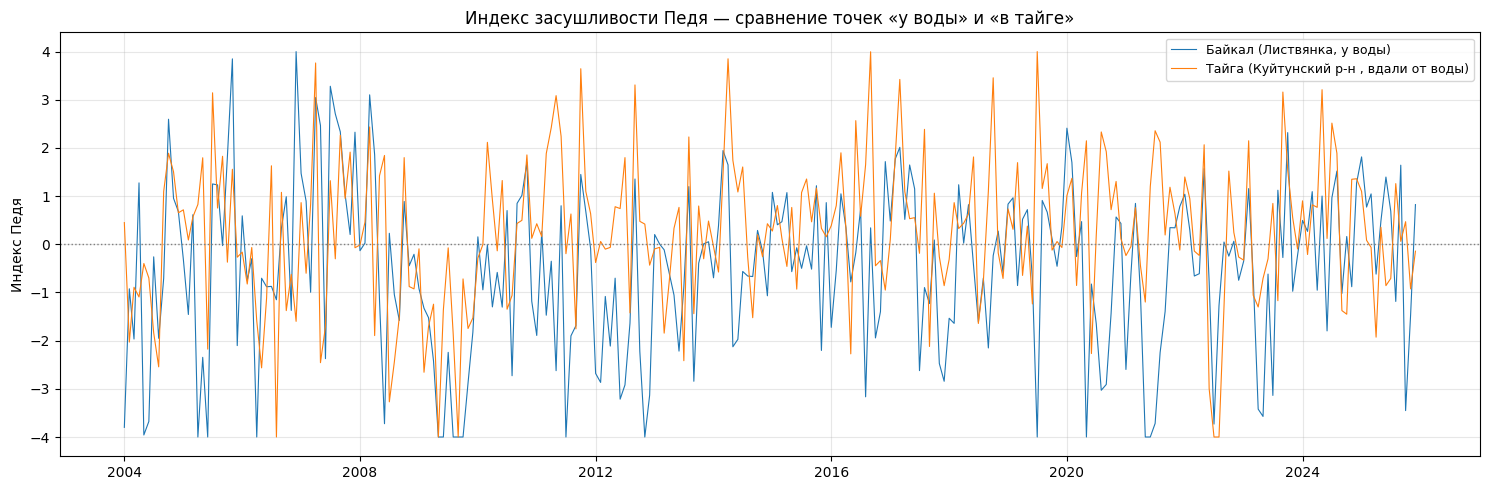

In [8]:
fig, ax = plt.subplots(figsize=(15, 5))
for label, (lat, lon) in points.items():
    series = ds_pedy["pedy_index"].sel(Lat=lat, Lon=lon, method="nearest")
    ax.plot(ds_pedy["Time"].values, series.values, lw=0.8, label=label)

ax.axhline(0, color="gray", linestyle=":", lw=1)
ax.set_title("Индекс засушливости Педя — сравнение точек «у воды» и «в тайге»")
ax.set_ylabel("Индекс Педя")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plots/pedy_water_vs_taiga.png", dpi=150)
plt.show()


**График 2** — средний сезонный ход (по месяцам) в тех же точках: показывает, в какие месяцы засушливость в среднем выше и насколько сильно отличаются точки друг от друга.

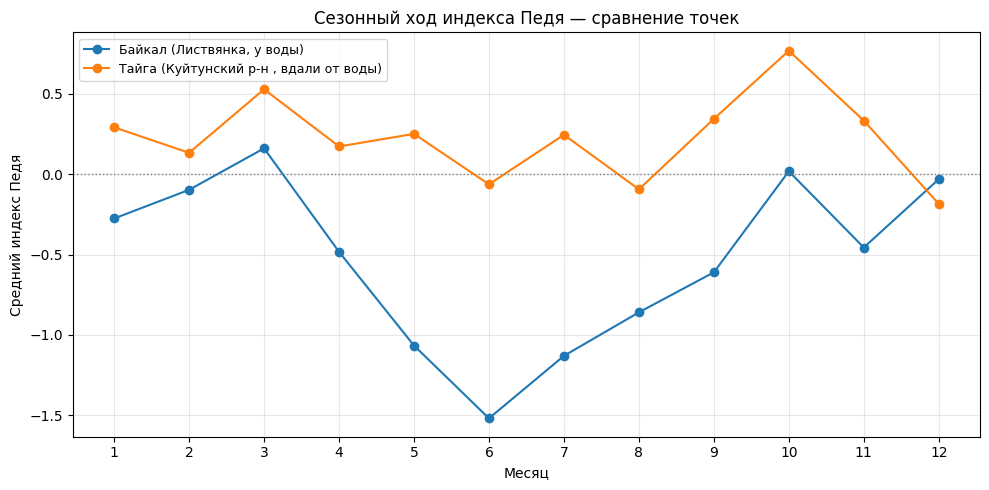

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, (lat, lon) in points.items():
    series = ds_pedy["pedy_index"].sel(Lat=lat, Lon=lon, method="nearest")
    monthly_mean = series.groupby("Time.month").mean()
    ax.plot(monthly_mean["month"].values, monthly_mean.values, marker="o", label=label)

ax.axhline(0, color="gray", linestyle=":", lw=1)
ax.set_xticks(range(1, 13))
ax.set_xlabel("Месяц")
ax.set_ylabel("Средний индекс Педя")
ax.set_title("Сезонный ход индекса Педя — сравнение точек")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plots/pedy_seasonal_cycle.png", dpi=150)
plt.show()


## Задача 4: Интеграция индекса засушливости с пожарными событиями. Исследование различных способов агрегации на основе оценки влияния на риск лесных пожаров.

Использовался набор пожарных и контрольных (не-пожарных) событий за период 2004–2024 гг. в формате GeoJSON, содержащий 106280 записей с координатами, датой события и целевой переменной `is_fire` (1 — пожар, 0 — контрольная точка).

In [116]:
import geopandas as gpd

gdf_fires = gpd.read_file("data/raw/fires_notfires.geojson")
ds_pedya = xr.open_dataset("data/processed/iki_2004-2025_pedy.nc")

gdf_fires.head()

,ID,fire_id,month,day,date_start,lon,lat,type,is_fire,elevation,...,WD_Восток,WD_Запад,WD_Север,WD_Северо-восток,WD_Северо-запад,WD_Юг,WD_Юго-восток,WD_Юго-запад,cluster,geometry
0,2004_71132,71132.0,6,26,2004-06-26 22:30:00,109.082000,61.269700,fire,1,368.0,...,0,1,0,0,0,0,0,1,0,POINT (109.082 61.2697)
1,2004_equal_0356,57745.0,10,22,2004-10-22 00:00:00,103.831865,53.590968,equal,0,639.0,...,0,0,1,0,1,1,1,0,1,POINT (103.83187 53.59097)
2,2004_equal_0355,57745.0,4,30,2004-04-30 00:00:00,98.229801,56.225488,equal,0,276.0,...,1,0,1,1,0,0,0,0,1,POINT (98.2298 56.22549)
3,2004_equal_0354,57745.0,8,5,2004-08-05 00:00:00,98.259910,54.776814,equal,0,827.0,...,1,0,1,1,1,0,0,0,1,POINT (98.25991 54.77681)
4,2004_equal_0353,57745.0,6,17,2004-06-17 00:00:00,102.786105,54.835486,equal,0,607.0,...,0,0,1,1,1,1,0,0,1,POINT (102.78611 54.83549)


**Методика привязки индекса засушливости к событиям**

Каждому событию было присвоено значение индекса засушливости Педя, соответствующее ближайшему узлу климатической сетки (0.25°) и определённому периоду, предшествующему дате события (временному сдвигу). Использование предшествующего периода обусловлено необходимостью оценки предсказательной, а не описательной ценности показателя: модель должна опираться на информацию, доступную до момента возникновения пожара.

Опробованы два способа определения временного сдвига:
- **Фиксированный сдвиг в 1 месяц** — индекс засушливости берётся за календарный месяц, предшествующий месяцу события, независимо от конкретного дня.
- **Адаптивный сдвиг** — учитывает день месяца, в котором произошло событие: для дат в первой половине месяца (1–15 число) используется индекс за предшествующий месяц, для дат во второй половине месяца (16–31 число) — индекс за текущий месяц события.

In [117]:
fire_dates = pd.to_datetime(gdf_fires['date_start'])

# Временной сдвиг 1 месяц (простой фиксированный сдвиг)
lag_dates_1 = (fire_dates - pd.DateOffset(months=1)).dt.to_period('M').dt.to_timestamp()

pedya_lag1 = ds_pedya.pedy_index.sel(
    Lat=xr.DataArray(gdf_fires['lat'].values, dims='points'),
    Lon=xr.DataArray(gdf_fires['lon'].values, dims='points'),
    Time=xr.DataArray(lag_dates_1.values, dims='points'),
    method='nearest'
)
gdf_fires['pedya_lag1'] = pedya_lag1.values

# Адаптивный временной сдвиг - учитывает день месяца события
day_of_month = fire_dates.dt.day
adaptive_lag_dates = pd.Series(index=gdf_fires.index, dtype='datetime64[ns]')

mask_early = day_of_month <= 15
mask_late = day_of_month > 15

adaptive_lag_dates[mask_early] = (fire_dates[mask_early] - pd.DateOffset(months=1)).dt.to_period('M').dt.to_timestamp()
adaptive_lag_dates[mask_late] = fire_dates[mask_late].dt.to_period('M').dt.to_timestamp()

pedya_adaptive = ds_pedya.pedy_index.sel(
    Lat=xr.DataArray(gdf_fires['lat'].values, dims='points'),
    Lon=xr.DataArray(gdf_fires['lon'].values, dims='points'),
    Time=xr.DataArray(adaptive_lag_dates.values, dims='points'),
    method='nearest'
)
gdf_fires['pedya_adaptive'] = pedya_adaptive.values

In [118]:
for col in ['pedya_lag1', 'pedya_adaptive']:
    valid = gdf_fires.dropna(subset=[col])
    corr = valid[col].corr(valid['is_fire'])
    mean_fire = valid[valid['is_fire'] == 1][col].mean()
    mean_no_fire = valid[valid['is_fire'] == 0][col].mean()
    print(f"{col}: корреляция = {corr:.4f}, среднее при пожаре = {mean_fire:.3f}, без пожара = {mean_no_fire:.3f}")

pedya_lag1: корреляция = 0.0226, среднее при пожаре = 0.197, без пожара = 0.103
pedya_adaptive: корреляция = 0.0749, среднее при пожаре = 0.415, без пожара = 0.098


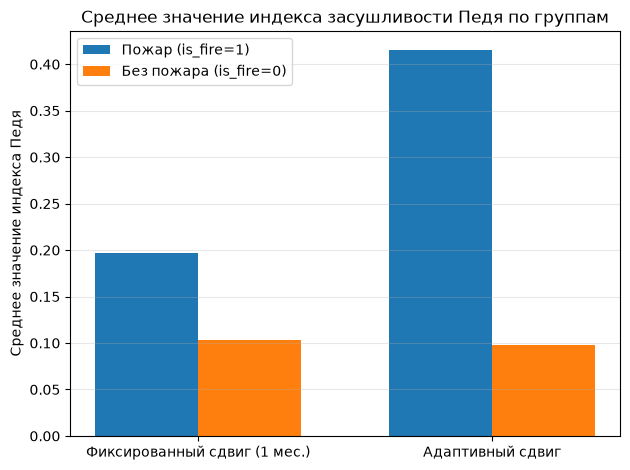

In [119]:
labels = ['Фиксированный сдвиг (1 мес.)', 'Адаптивный сдвиг']
mean_fire = [0.197, 0.415]
mean_no_fire = [0.103, 0.098]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, mean_fire, width, label='Пожар (is_fire=1)')
ax.bar(x + width/2, mean_no_fire, width, label='Без пожара (is_fire=0)')

ax.set_ylabel('Среднее значение индекса Педя')
ax.set_title('Среднее значение индекса засушливости Педя по группам')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Результаты сравнения способов агрегации**

| Способ агрегации | Корреляция с is_fire | Среднее при пожаре | Среднее без пожара |
|---|---|---|---|
| Фиксированный сдвиг (1 месяц) | 0.023 | 0.197 | 0.103 |
| Адаптивный сдвиг | 0.075 | 0.415 | 0.098 |

Адаптивный способ агрегации продемонстрировал более чем трёхкратное превышение корреляции с риском пожара по сравнению с фиксированным сдвигом (0.075 против 0.023), а также значительно большую разницу средних значений индекса засушливости между пожарными и контрольными точками (0.415 против 0.197 при пожаре, при практически неизменном среднем для контрольных точек — 0.098 против 0.103). Это подтверждает, что точность временной привязки индекса засушливости к дате события существенно влияет на его предсказательную ценность, и адаптивный способ агрегации был принят как основной для дальнейшего анализа.

### Задача 5: Статистический анализ пожаров и индекса засушливости, осадков, температуры

Для количественной оценки связи гидрометеорологических показателей с риском возникновения пожара каждому событию (`gdf_fires`) были присвоены значения индекса засушливости Педя, температуры и осадков с использованием адаптивного временного сдвига, показавшего наилучшие результаты на предыдущем этапе анализа.

In [120]:
for var_name, ds_var in [('temp', ds_iki_interp.T_mean), ('precip', ds_iki_interp.APCP)]:
    values = ds_var.sel(
        Lat=xr.DataArray(gdf_fires['lat'].values, dims='points'),
        Lon=xr.DataArray(gdf_fires['lon'].values, dims='points'),
        Time=xr.DataArray(adaptive_lag_dates.values, dims='points'),
        method='nearest'
    )
    gdf_fires[f'{var_name}_adaptive'] = values.values

for col in ['pedya_adaptive', 'temp_adaptive', 'precip_adaptive']:
    valid = gdf_fires.dropna(subset=[col])
    corr = valid[col].corr(valid['is_fire'])
    mean_fire = valid[valid['is_fire'] == 1][col].mean()
    mean_no_fire = valid[valid['is_fire'] == 0][col].mean()
    print(f"{col}: корреляция с is_fire = {corr:.4f}, среднее при пожаре = {mean_fire:.3f}, без пожара = {mean_no_fire:.3f}")

pedya_adaptive: корреляция с is_fire = 0.0749, среднее при пожаре = 0.415, без пожара = 0.098
temp_adaptive: корреляция с is_fire = 0.0412, среднее при пожаре = 7.384, без пожара = 6.554
precip_adaptive: корреляция с is_fire = -0.1912, среднее при пожаре = 59.341, без пожара = 79.561


**Связь показателей с риском пожара**

| Показатель | Корреляция с is_fire | Среднее при пожаре | Среднее без пожара |
|---|---|---|---|
| Индекс засушливости Педя | 0.075 | 0.415 | 0.098 |
| Температура, °C | 0.041 | 7.384 | 6.554 |
| Осадки, мм | −0.191 | 59.341 | 79.561 |

Наиболее выраженную связь с риском пожара среди рассмотренных показателей демонстрируют осадки (r = −0.191): чем меньше осадков выпало в предшествующий период, тем выше вероятность возникновения пожара. Индекс засушливости Педя занимает второе место по силе связи (r = 0.075), температура показывает наиболее слабую связь (r = 0.041).

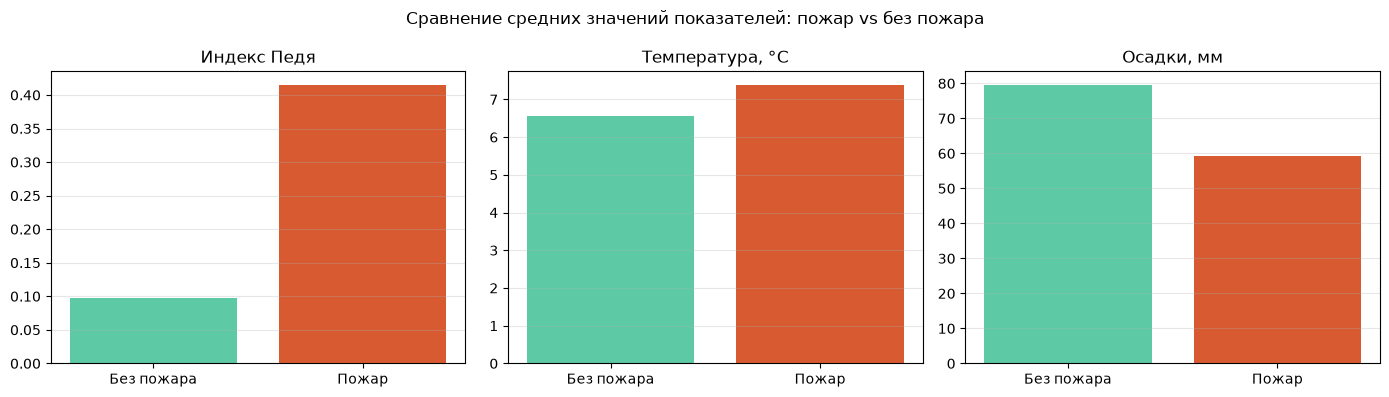

In [121]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

data = {
    'pedya_adaptive': ('Индекс Педя', 0.415, 0.098),
    'temp_adaptive': ('Температура, °C', 7.384, 6.554),
    'precip_adaptive': ('Осадки, мм', 59.341, 79.561)
}

for ax, (col, (title, mean_fire, mean_no_fire)) in zip(axes, data.items()):
    ax.bar(['Без пожара', 'Пожар'], [mean_no_fire, mean_fire], color=['#5DCAA5', '#D85A30'])
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Сравнение средних значений показателей: пожар vs без пожара')
plt.tight_layout()
plt.show()

Диаграмма наглядно иллюстрирует направление связи каждого показателя с риском пожара: индекс засушливости Педя и температура выше при пожаре, тогда как осадки, напротив, ниже — что согласуется с физической природой явления: сухость и тепло способствуют возникновению пожара, тогда как достаточное количество осадков снижает его вероятность.

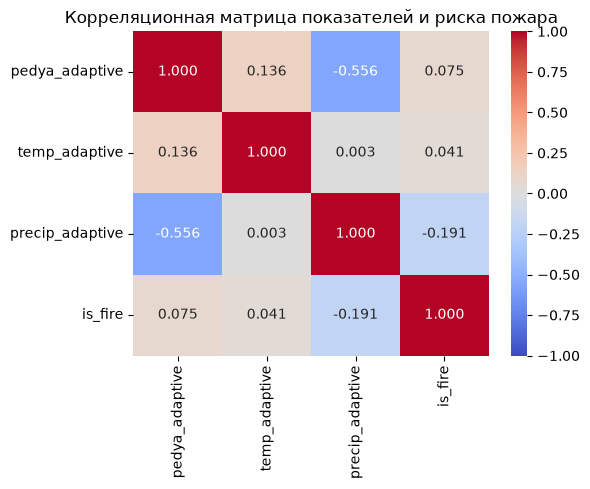

In [122]:
corr_matrix = gdf_fires[['pedya_adaptive', 'temp_adaptive', 'precip_adaptive', 'is_fire']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Корреляционная матрица показателей и риска пожара')
plt.tight_layout()
plt.savefig("corr1.png")
plt.show()

Корреляционный анализ показателей между собой выявил слабую положительную связь температуры и осадков (r = 0.003). Индекс засушливости Педя демонстрирует выраженную отрицательную связь с осадками (r = −0.556), что ожидаемо, поскольку осадки являются одним из ключевых компонентов формулы индекса, и слабую положительную связь с температурой (r = 0.136). При этом связь индекса Педя с фактическим риском пожара (r = 0.075) оказывается слабее прямой связи одних только осадков (r = −0.191), что указывает на ведущую роль влагообеспеченности в формировании пожарной опасности для рассматриваемого региона.

Таким образом, среди рассмотренных гидрометеорологических показателей ведущим фактором риска возникновения лесного пожара в Иркутской области выступает влагообеспеченность (осадки), тогда как температура играет второстепенную роль.

### Задача 6: Сравнение влияния исходных и скорректированных гидрометеорологических данных на риск лесных пожаров
Для оценки влияния коррекции гидрометеорологических данных на их предсказательную способность относительно риска пожара было выполнено сравнение температуры, осадков и индекса засушливости Педя, рассчитанных на исходных (нескорректированных) и скорректированных данных. Для честности сравнения использовалось общее подмножество событий, для которых значения доступны в обеих версиях данных одновременно.

In [123]:
PATH_FIRES = "data/processed/fires_with_pedya.geojson"
PATH_CORRECTED = "data/processed/iki_2004-2025_pedy.nc"  # скорректированные T_mean/APCP + индекс Педя
PATH_RAW = "data/processed/iki_025_old_pedy.nc"          # исходные T_mean/APCP + индекс Педя

gdf_fires = gpd.read_file(PATH_FIRES)
ds_corrected = xr.open_dataset(PATH_CORRECTED)
ds_raw = xr.open_dataset(PATH_RAW)

fire_dates = pd.to_datetime(gdf_fires['date_start'])
day_of_month = fire_dates.dt.day

adaptive_lag_dates = pd.Series(index=gdf_fires.index, dtype='datetime64[ns]')
mask_early = day_of_month <= 15
mask_late = day_of_month > 15
adaptive_lag_dates[mask_early] = (fire_dates[mask_early] - pd.DateOffset(months=1)).dt.to_period('M').dt.to_timestamp()
adaptive_lag_dates[mask_late] = fire_dates[mask_late].dt.to_period('M').dt.to_timestamp()

In [124]:
for label, ds in [('corrected', ds_corrected), ('raw', ds_raw)]:
    values = ds.pedy_index.sel(
        Lat=xr.DataArray(gdf_fires['lat'].values, dims='points'),
        Lon=xr.DataArray(gdf_fires['lon'].values, dims='points'),
        Time=xr.DataArray(adaptive_lag_dates.values, dims='points'),
        method='nearest'
    )
    gdf_fires[f'pedya_{label}'] = values.values

common_valid = gdf_fires.dropna(subset=['pedya_corrected', 'pedya_raw'])
print(f"Записей для честного сравнения: {len(common_valid)} из {len(gdf_fires)}")

corr_corrected = common_valid['pedya_corrected'].corr(common_valid['is_fire'])
corr_raw = common_valid['pedya_raw'].corr(common_valid['is_fire'])

mean_fire_corr = common_valid[common_valid['is_fire']==1]['pedya_corrected'].mean()
mean_no_fire_corr = common_valid[common_valid['is_fire']==0]['pedya_corrected'].mean()
mean_fire_raw = common_valid[common_valid['is_fire']==1]['pedya_raw'].mean()
mean_no_fire_raw = common_valid[common_valid['is_fire']==0]['pedya_raw'].mean()

print(f"Скорректированные: r = {corr_corrected:.4f}, при пожаре = {mean_fire_corr:.3f}, без пожара = {mean_no_fire_corr:.3f}")
print(f"Исходные: r = {corr_raw:.4f}, при пожаре = {mean_fire_raw:.3f}, без пожара = {mean_no_fire_raw:.3f}")

Записей для честного сравнения: 95530 из 106280
Скорректированные: r = 0.0930, при пожаре = 0.516, без пожара = 0.126
Исходные: r = 0.0996, при пожаре = 0.696, без пожара = 0.236


In [125]:
for var_name, ds_corr_var, ds_raw_var in [
    ('temp', ds_corrected.T_mean, ds_raw.T_mean),
    ('precip', ds_corrected.APCP, ds_raw.APCP)
]:
    values_corrected = ds_corr_var.sel(
        Lat=xr.DataArray(gdf_fires['lat'].values, dims='points'),
        Lon=xr.DataArray(gdf_fires['lon'].values, dims='points'),
        Time=xr.DataArray(adaptive_lag_dates.values, dims='points'),
        method='nearest'
    )
    gdf_fires[f'{var_name}_corrected'] = values_corrected.values

    values_raw = ds_raw_var.sel(
        Lat=xr.DataArray(gdf_fires['lat'].values, dims='points'),
        Lon=xr.DataArray(gdf_fires['lon'].values, dims='points'),
        Time=xr.DataArray(adaptive_lag_dates.values, dims='points'),
        method='nearest'
    )
    gdf_fires[f'{var_name}_raw'] = values_raw.values

pairs = [
    ('temp_raw', 'temp_corrected', 'Температура'),
    ('precip_raw', 'precip_corrected', 'Осадки'),
    ('pedya_raw', 'pedya_corrected', 'Индекс Педя')
]

for raw_col, corr_col, label in pairs:
    common = gdf_fires.dropna(subset=[raw_col, corr_col])
    corr_raw = common[raw_col].corr(common['is_fire'])
    corr_corrected = common[corr_col].corr(common['is_fire'])

    print(f"{label}:")
    print(f"Исходные: r = {corr_raw:.4f}")
    print(f"Скорректированные: r = {corr_corrected:.4f}")
    print(f"Изменение: {corr_corrected - corr_raw:+.4f}\n")

Температура:
Исходные: r = 0.0412
Скорректированные: r = 0.0376
Изменение: -0.0037

Осадки:
Исходные: r = -0.1912
Скорректированные: r = -0.1857
Изменение: +0.0055

Индекс Педя:
Исходные: r = 0.0996
Скорректированные: r = 0.0930
Изменение: -0.0066



**Итоговая сводка**

| Показатель | Записей | Исходные (r) | Скорректированные (r) | Изменение |
|---|---|---|---|---|
| Температура | 102232 | 0.0412 | 0.0376 | −0.0037 |
| Осадки | 102232 | −0.1912 | −0.1857 | +0.0055 |
| Индекс Педя | 95530 | 0.0996 | 0.0930 | −0.0066 |

Изменение корреляции при коррекции данных во всех трёх случаях незначительно (в пределах ±0.007) и не имеет единого направления: снижение наблюдается для температуры и индекса Педя, повышение — для осадков. Это указывает на то, что систематическое смещение исходных данных в равной степени затрагивает как пожарные, так и контрольные (не-пожарные) наблюдения, вследствие чего не искажает относительное сравнение между группами и не оказывает существенного влияния на предсказательную способность показателей в задаче классификации пожарных событий.

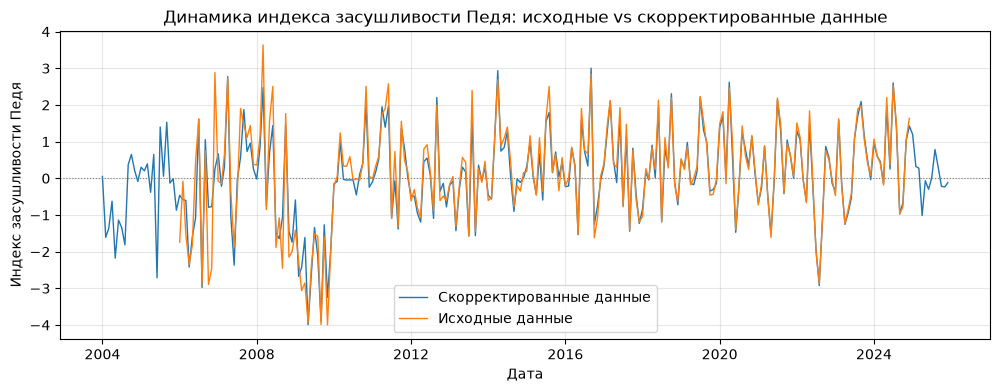

In [126]:
pedya_corrected_ts = ds_corrected.pedy_index.mean(dim=['Lat', 'Lon'])
pedya_raw_ts = ds_raw.pedy_index.mean(dim=['Lat', 'Lon'])

plt.figure(figsize=(12, 4))
plt.plot(ds_corrected.Time.values, pedya_corrected_ts.values, label='Скорректированные данные', linewidth=1)
plt.plot(ds_raw.Time.values, pedya_raw_ts.values, label='Исходные данные', linewidth=1)
plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)
plt.xlabel('Дата')
plt.ylabel('Индекс засушливости Педя')
plt.title('Динамика индекса засушливости Педя: исходные vs скорректированные данные')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

График демонстрирует, что скорректированные данные покрывают более ранний период (с 2004 г.), тогда как исходные данные становятся доступны позднее — вследствие расширения скорректированного ряда назад для покрытия периода "разгона" индекса засушливости. На протяжении большей части периода наблюдений (начиная примерно с 2010 г.) обе кривые демонстрируют высокую степень согласованности, что подтверждает устойчивость общей динамики индекса засушливости к применённой коррекции.

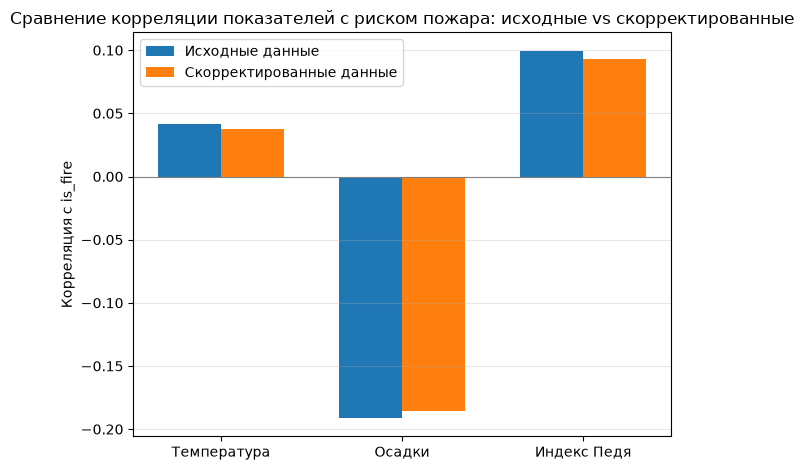

In [127]:
labels = ['Температура', 'Осадки', 'Индекс Педя']
corr_raw_vals = [0.0412, -0.1912, 0.0996]
corr_corrected_vals = [0.0376, -0.1857, 0.0930]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, corr_raw_vals, width, label='Исходные данные')
ax.bar(x + width/2, corr_corrected_vals, width, label='Скорректированные данные')

ax.set_ylabel('Корреляция с is_fire')
ax.set_title('Сравнение корреляции показателей с риском пожара: исходные vs скорректированные')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.axhline(0, color='gray', linewidth=0.8)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('comp1.png')
plt.show()

Диаграмма наглядно подтверждает вывод о минимальном влиянии коррекции на предсказательную способность показателей: для каждого из трёх показателей столбцы, соответствующие исходным и скорректированным данным, практически совпадают по высоте. Наиболее заметная (хотя всё ещё небольшая) разница наблюдается для индекса засушливости Педя, тогда как для температуры и осадков коррекция практически не отражается на силе связи с риском пожара.

### Задача 7: Обучение модели Random Forest

В данном разделе выполняется обучение модели классификации Random Forest на основе 24 географических и гидрометеорологических факторов для прогнозирования риска возникновения лесного пожара (is_fire). Набор признаков и методика основаны на подходе, описанном в диссертации [https://sibsutis.ru/upload/iblock/c73/Диссертация.pdf#page=101.64]. Перед обучением модели проведён предварительный корреляционный анализ статичных (не зависящих от времени) факторов — топографических, характеризующих растительный покров и социально-инфраструктурных, — для оценки их потенциальной значимости.

In [128]:
df_model = gdf_fires[gdf_fires['type'].isin(['fire', 'inverse'])].copy()

In [129]:
topo_features = ['elevation', 'slope', 'aspect']
veg_features = ['vegetation', 'is_лиственница-8', 'is_ель-11']
social_features = ['MO_population', 'dist_to_settlements', 'dist_to_roads', 'dist_to_railway', 'dist_to_rivers']

all_group_features = topo_features + veg_features + social_features

correlations = {}
for col in all_group_features:
    valid = df_model.dropna(subset=[col])
    correlations[col] = valid[col].corr(valid['is_fire'])

corr_series = pd.Series(correlations).sort_values()
print(corr_series)

dist_to_settlements   -0.325692
dist_to_railway       -0.316421
dist_to_roads         -0.308829
vegetation            -0.275502
elevation             -0.176621
is_ель-11             -0.168392
is_лиственница-8      -0.157694
slope                 -0.142789
dist_to_rivers        -0.071389
aspect                -0.030423
MO_population          0.172738
dtype: float64


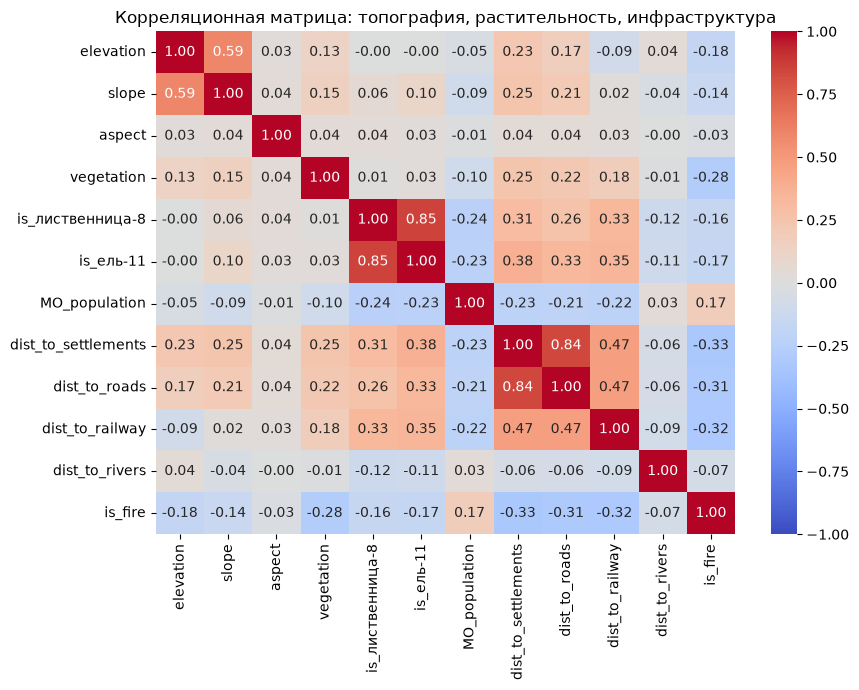

In [130]:
corr_matrix_groups = df_model[all_group_features + ['is_fire']].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix_groups, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Корреляционная матрица: топография, растительность, инфраструктура')
plt.tight_layout()
plt.show()

Анализ корреляции топографических, растительных и социально-инфраструктурных факторов с риском пожара показал, что наиболее сильную связь демонстрируют показатели удалённости от объектов инфраструктуры: расстояние до населённых пунктов (r = −0.33), железной дороги (r = −0.32) и автомобильных дорог (r = −0.31). Отрицательный знак корреляции указывает на то, что пожары чаще происходят в непосредственной близости к местам человеческой активности, что согласуется с преобладающей ролью антропогенного фактора в возникновении лесных пожаров. Численность населения муниципального образования (MO_population) демонстрирует положительную связь с риском пожара (r = 0.17).

Топографические факторы (высота над уровнем моря, уклон, экспозиция склона) показали более слабую связь с риском пожара по сравнению с инфраструктурными показателями, с наибольшим значением у высоты над уровнем моря (r = −0.18).

Также выявлена высокая взаимная корреляция между отдельными парами признаков — в частности, между расстоянием до населённых пунктов и до дорог (r = 0.84), а также между индикаторами двух пород деревьев (r = 0.85), что свидетельствует о мультиколлинеарности в данном наборе признаков. Несмотря на устойчивость метода Random Forest к мультиколлинеарности, данное обстоятельство может влиять на распределение важности между сходными признаками.

In [131]:
meteo_features = [
    'kpo', 'danger_class', 'n',
    '3_days_AVG_TMP', '3_days_AVG_SOILW', '3_days_SUM_APCP', '3_days_AVG_RH',
    'SNOD_baseline', 'SNOD_recent', '14_days_AVG_SOILT100', '3_days_AVG_SOILT200',
    'WD_Юг', 'WD_Юго-восток'
]

correlations_meteo = {}
for col in meteo_features:
    valid = df_model.dropna(subset=[col])
    correlations_meteo[col] = valid[col].corr(valid['is_fire'])

corr_series_meteo = pd.Series(correlations_meteo).sort_values()
print(corr_series_meteo)

3_days_AVG_RH          -0.454343
3_days_SUM_APCP        -0.358347
3_days_AVG_SOILW       -0.341558
SNOD_baseline          -0.250858
14_days_AVG_SOILT100   -0.230700
SNOD_recent            -0.228951
3_days_AVG_SOILT200    -0.180410
WD_Юг                   0.150520
WD_Юго-восток           0.185454
kpo                     0.308460
3_days_AVG_TMP          0.312519
n                       0.314204
danger_class            0.375714
dtype: float64


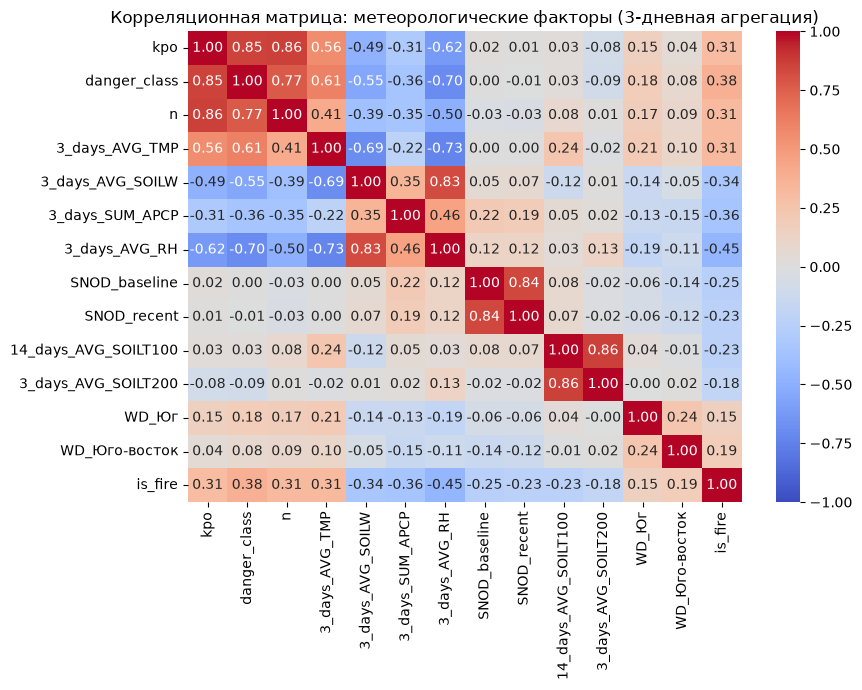

In [132]:
corr_matrix_meteo = df_model[meteo_features + ['is_fire']].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix_meteo, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Корреляционная матрица: метеорологические факторы (3-дневная агрегация)')
plt.tight_layout()
plt.show()

Корреляционный анализ метеорологических факторов, агрегированных за трёх- и четырнадцатидневный период, показал существенно более выраженную связь с риском пожара по сравнению с топографическими и социальными факторами. Наиболее сильную связь демонстрируют категориальный класс пожарной опасности danger_class (r = 0.38), количественный показатель Нестерова kpo и число дней после последнего дождя n (r = 0.31 для обоих), температура за предшествующие три дня (r = 0.31), а также относительная влажность воздуха за три дня (r = −0.45) — наиболее сильная отрицательная связь среди всех рассмотренных показателей.

In [133]:
features_24 = [
    "elevation", "slope", "aspect", "vegetation", "is_лиственница-8", "is_ель-11",
    "MO_population", "dist_to_railway", "dist_to_roads", "dist_to_rivers", "dist_to_settlements",
    "kpo", "danger_class", "n",
    "3_days_AVG_TMP", "3_days_AVG_SOILW", "3_days_SUM_APCP", "3_days_AVG_RH",
    "SNOD_baseline", "SNOD_recent", "14_days_AVG_SOILT100", "3_days_AVG_SOILT200",
    "WD_Юг", "WD_Юго-восток"
]

X = df_model[features_24]
y = df_model['is_fire']

print(X.isnull().sum())

elevation                   0
slope                       0
aspect                      0
vegetation                  0
is_лиственница-8        10927
is_ель-11               10927
MO_population               0
dist_to_railway             0
dist_to_roads               0
dist_to_rivers              0
dist_to_settlements         0
kpo                         0
danger_class                0
n                           0
3_days_AVG_TMP              0
3_days_AVG_SOILW            0
3_days_SUM_APCP             0
3_days_AVG_RH               0
SNOD_baseline               0
SNOD_recent                 0
14_days_AVG_SOILT100        0
3_days_AVG_SOILT200         0
WD_Юг                       0
WD_Юго-восток               0
dtype: int64


In [134]:
X = X.copy()
X['is_лиственница-8'] = X['is_лиственница-8'].fillna(0)
X['is_ель-11'] = X['is_ель-11'].fillna(0)

print(X.isnull().sum().sum())  # должно быть 0

0


**Параметры модели**

Для обучения использован алгоритм `RandomForestClassifier` из библиотеки `scikit-learn` со следующими гиперпараметрами:
- `n_estimators = 500` — число деревьев в ансамбле, обеспечивающее устойчивость модели к переобучению за счёт усреднения большого числа независимых деревьев;
- `min_samples_leaf = 4` — минимальное число наблюдений в листовом узле, ограничивающее излишнюю детализацию отдельных деревьев;
- `min_samples_split = 10` — минимальное число наблюдений, необходимое для разбиения узла.

Значения параметров приняты по аналогии с методикой, описанной в источнике [диссертация], как обоснованная отправная точка для построения базовой модели без дополнительного подбора гиперпараметров.

In [135]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(n_estimators=500, min_samples_leaf=4, min_samples_split=10, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootst

In [136]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['inverse (0)', 'fire (1)']))

              precision    recall  f1-score   support

 inverse (0)       0.88      0.86      0.87      5314
    fire (1)       0.87      0.88      0.87      5314

    accuracy                           0.87     10628
   macro avg       0.87      0.87      0.87     10628
weighted avg       0.87      0.87      0.87     10628



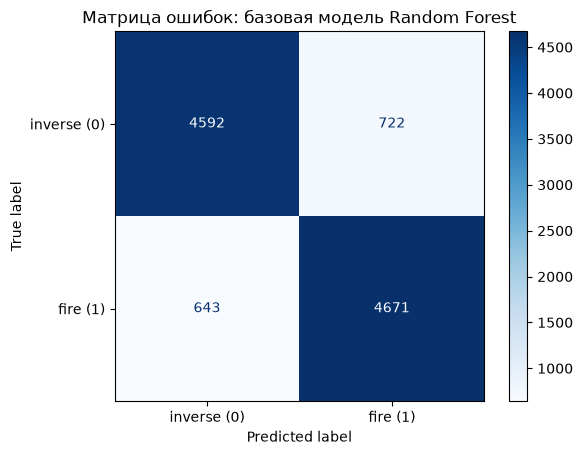

In [137]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['inverse (0)', 'fire (1)'])
disp.plot(cmap='Blues')
plt.title('Матрица ошибок: базовая модель Random Forest')
plt.savefig("conf_matrix.png")
plt.show()

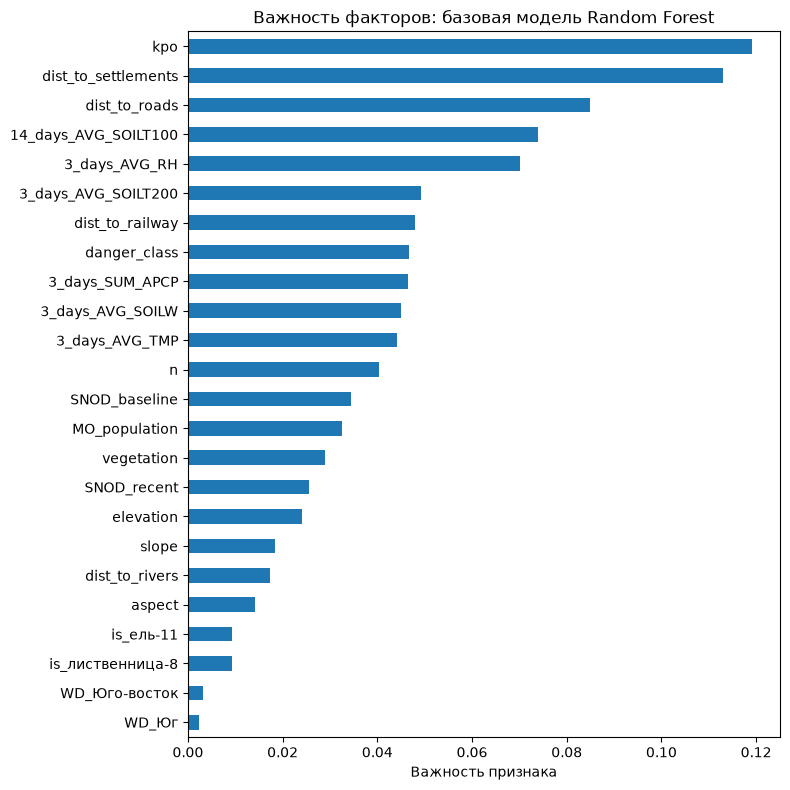

In [138]:
importances = pd.Series(rf_model.feature_importances_, index=features_24).sort_values(ascending=True)

plt.figure(figsize=(8, 8))
importances.plot(kind='barh')
plt.xlabel('Важность признака')
plt.title('Важность факторов: базовая модель Random Forest')
plt.tight_layout()
plt.savefig('factors.png')
plt.show()

Базовая модель Random Forest, обученная на 24 признаках со случайным разбиением на обучающую и тестовую выборки (80/20), продемонстрировала следующие метрики качества: accuracy = 0.87, F1-score = 0.87 (сбалансированно для обоих классов). Полученные значения сопоставимы с результатами, приведёнными в источнике методики (F1-score 0.826–0.949).

Матрица ошибок показывает практически симметричное распределение ошибок между классами: 722 ложноположительных и 643 ложноотрицательных случая из 10628 тестовых наблюдений.

Анализ важности признаков выявил, что наиболее значимым фактором является количественный показатель Нестерова (kpo), за которым следуют дистанции до населённых пунктов и дорог. Примечательно, что количественная метрика показателя Нестерова (kpo) оказалась заметно важнее его категориального производного (danger_class), что согласуется с ранее опубликованными результатами по данной методике и может свидетельствовать о потере информации при переходе от непрерывной шкалы показателя к дискретным классам пожарной опасности.

### Обучение модели со скорректированными данными

Для оценки влияния коррекции данных на качество модели выполнена замена показателей температуры и осадков за предшествующий трёхдневный период (`3_days_AVG_TMP`, `3_days_SUM_APCP`) на значения, рассчитанные на скорректированных данных. Показатель Нестерова (`kpo`, `danger_class`, `n`) оставлен без изменений в соответствии с указанием руководителя практики, поскольку его пересчёт на скорректированных данных требует пересчёта самой формулы на посуточном уровне и выходит за рамки текущего этапа работы.

In [139]:
ds_new = xr.open_dataset("data/processed/3_average.nc")
print(ds_new)

<xarray.Dataset> Size: 579MB
Dimensions:        (time: 7624, lat: 51, lon: 93)
Coordinates:
  * time           (time) datetime64[ns] 61kB 2004-01-03 ... 2025-01-01
  * lat            (lat) float64 408B 64.0 63.75 63.5 63.25 ... 52.0 51.75 51.5
  * lon            (lon) float64 744B 96.0 96.25 96.5 ... 118.5 118.8 119.0
Data variables:
    avg_temp_3d    (time, lat, lon) float64 289MB ...
    precip_sum_3d  (time, lat, lon) float64 289MB ...
Attributes:
    description:  3-day rolling temperature average and precipitation sum


In [140]:
fire_dates_model = pd.to_datetime(df_model['date_start'])

temp_corr_values = ds_new.avg_temp_3d.sel(
    lat=xr.DataArray(df_model['lat'].values, dims='points'),
    lon=xr.DataArray(df_model['lon'].values, dims='points'),
    time=xr.DataArray(fire_dates_model.values, dims='points'),
    method='nearest'
)
df_model['3_days_AVG_TMP_corrected'] = temp_corr_values.values

precip_corr_values = ds_new.precip_sum_3d.sel(
    lat=xr.DataArray(df_model['lat'].values, dims='points'),
    lon=xr.DataArray(df_model['lon'].values, dims='points'),
    time=xr.DataArray(fire_dates_model.values, dims='points'),
    method='nearest'
)
df_model['3_days_SUM_APCP_corrected'] = precip_corr_values.values

print(df_model[['3_days_AVG_TMP', '3_days_AVG_TMP_corrected', '3_days_SUM_APCP', '3_days_SUM_APCP_corrected']].describe())

       3_days_AVG_TMP  3_days_AVG_TMP_corrected  3_days_SUM_APCP  \
count    53140.000000              51399.000000     53140.000000   
mean        14.534024                 15.073770         7.384969   
std          9.620177                  9.763173         9.335319   
min        -18.252500                -19.383333         0.000000   
25%          7.475000                  7.896667         1.000000   
50%         14.702500                 15.503333         4.360000   
75%         22.107500                 22.726667        10.300000   
max         38.307500                 38.525000       114.200000   

       3_days_SUM_APCP_corrected  
count               51399.000000  
mean                    5.765359  
std                     8.309115  
min                     0.000000  
25%                     0.475000  
50%                     3.000000  
75%                     7.717500  
max                   169.250000  


In [141]:
df_model_corrected = df_model.dropna(subset=['3_days_AVG_TMP_corrected', '3_days_SUM_APCP_corrected']).copy()
print(len(df_model_corrected))

features_corrected = features_24.copy()
features_corrected[features_corrected.index('3_days_AVG_TMP')] = '3_days_AVG_TMP_corrected'
features_corrected[features_corrected.index('3_days_SUM_APCP')] = '3_days_SUM_APCP_corrected'

X_corrected = df_model_corrected[features_corrected].copy()
X_corrected['is_лиственница-8'] = X_corrected['is_лиственница-8'].fillna(0)
X_corrected['is_ель-11'] = X_corrected['is_ель-11'].fillna(0)

y_corrected = df_model_corrected['is_fire']

print(X_corrected.isnull().sum().sum())  # должно быть 0

51399
0


In [142]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_corrected, y_corrected, test_size=0.2, random_state=42, stratify=y_corrected
)

rf_model_corrected = RandomForestClassifier(n_estimators=500, min_samples_leaf=4, min_samples_split=10, random_state=42)
rf_model_corrected.fit(X_train2, y_train2)

y_pred2 = rf_model_corrected.predict(X_test2)
print(classification_report(y_test2, y_pred2, target_names=['inverse (0)', 'fire (1)']))

              precision    recall  f1-score   support

 inverse (0)       0.88      0.86      0.87      5067
    fire (1)       0.87      0.89      0.88      5213

    accuracy                           0.87     10280
   macro avg       0.88      0.87      0.87     10280
weighted avg       0.87      0.87      0.87     10280



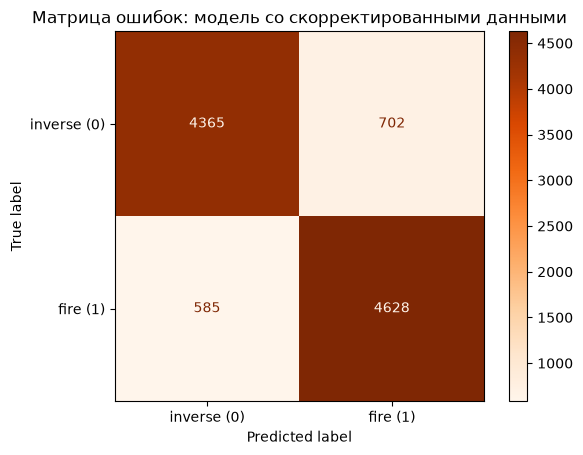

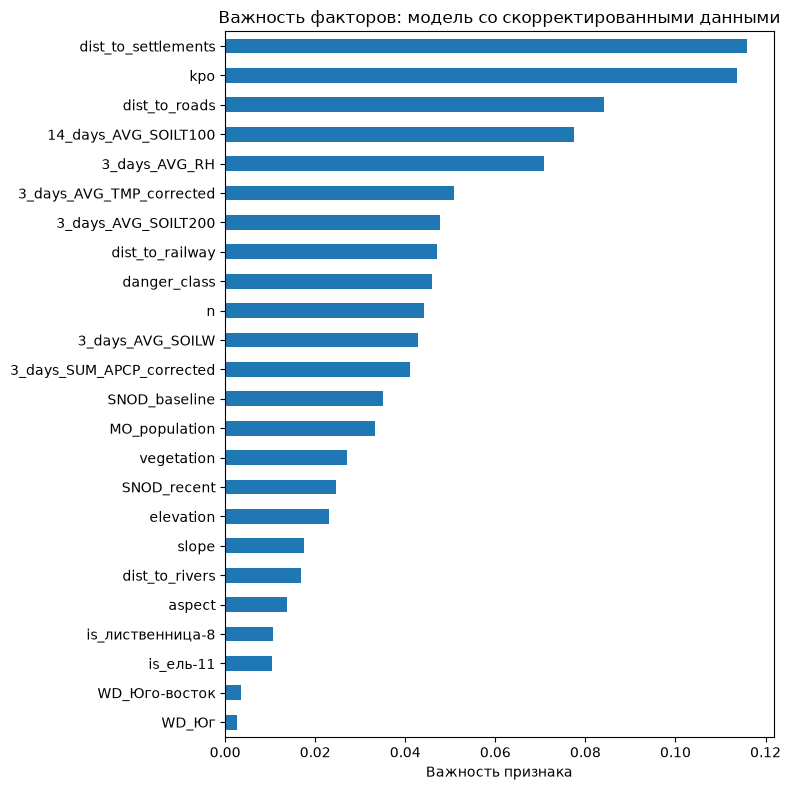

In [143]:
cm2 = confusion_matrix(y_test2, y_pred2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['inverse (0)', 'fire (1)'])
disp2.plot(cmap='Oranges')
plt.title('Матрица ошибок: модель со скорректированными данными')
plt.show()

importances2 = pd.Series(rf_model_corrected.feature_importances_, index=features_corrected).sort_values(ascending=True)

plt.figure(figsize=(8, 8))
importances2.plot(kind='barh')
plt.xlabel('Важность признака')
plt.title('Важность факторов: модель со скорректированными данными')
plt.tight_layout()
plt.show()

**Сравнение базовой и скорректированной моделей**

Замена показателей температуры и осадков за трёхдневный период на скорректированные значения (рассчитанные на сетке 0.25°) не привела к существенному изменению общего качества модели: accuracy сохранилась на уровне 0.87, F1-score — 0.87–0.88. Матрица ошибок демонстрирует небольшое снижение числа как ложноположительных (702 против 722), так и ложноотрицательных (585 против 643) предсказаний.

Анализ важности признаков выявил перестановку в верхней части рейтинга: расстояние до населённых пунктов (dist_to_settlements) стало наиболее значимым признаком, обойдя количественный показатель Нестерова (kpo), который занимал первое место в базовой модели. Оба показателя остаются близкими по значению важности и совместно формируют ведущую группу факторов. Скорректированные показатели температуры и осадков заняли позиции, сопоставимые с их исходными аналогами в базовой модели, без существенного изменения относительной значимости.

Таким образом, коррекция климатических данных не оказывает значимого влияния на общее качество классификации и лишь незначительно перераспределяет важность между близкими по значимости факторами, что согласуется с результатами статистического анализа (раздел 6), где также было установлено отсутствие существенного эффекта коррекции на предсказательную силу отдельных показателей.

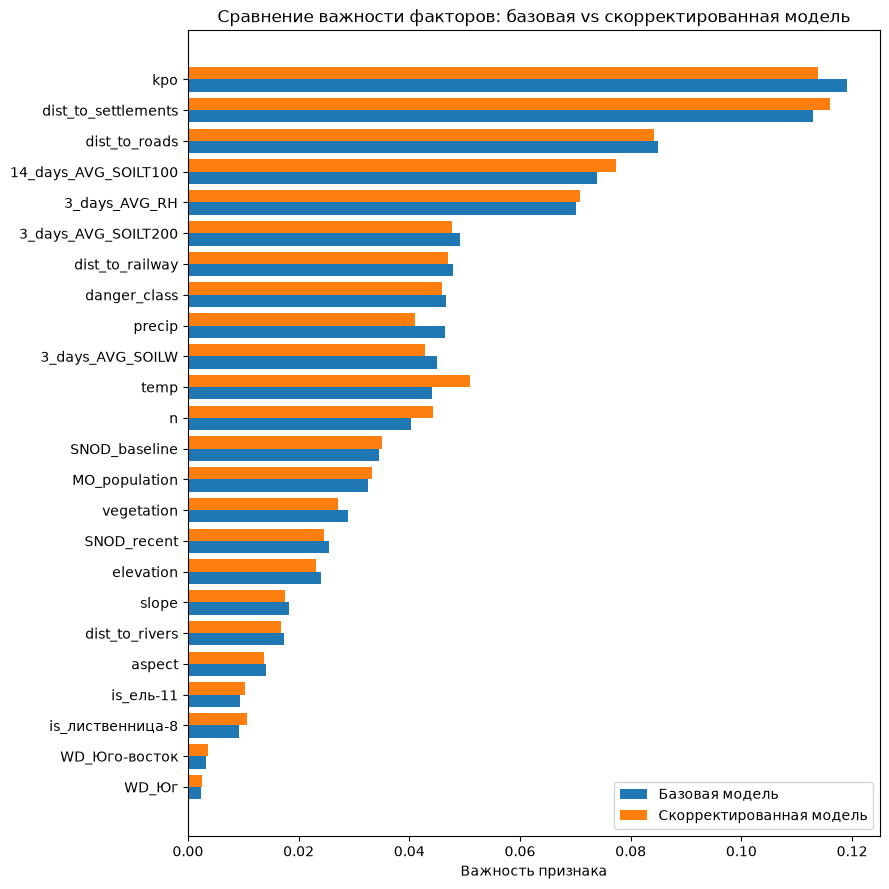

In [145]:
importances_df = pd.DataFrame({
    'feature_base': features_24,
    'importance_base': importances.reindex(features_24).values
})

corrected_map = dict(zip(
    [f.replace('_corrected', '').replace('3_days_AVG_TMP', 'temp').replace('3_days_SUM_APCP', 'precip') for f in features_corrected],
    importances2.reindex(features_corrected).values
))

importances_df['feature_key'] = importances_df['feature_base'].str.replace('3_days_AVG_TMP', 'temp', regex=False).str.replace('3_days_SUM_APCP', 'precip', regex=False)
importances_df['importance_corrected'] = importances_df['feature_key'].map(corrected_map)

importances_df = importances_df.sort_values('importance_base', ascending=True)

fig, ax = plt.subplots(figsize=(9, 9))
y_pos = np.arange(len(importances_df))
width = 0.4

ax.barh(y_pos - width/2, importances_df['importance_base'], height=width, label='Базовая модель')
ax.barh(y_pos + width/2, importances_df['importance_corrected'], height=width, label='Скорректированная модель')

ax.set_yticks(y_pos)
ax.set_yticklabels(importances_df['feature_key'])
ax.set_xlabel('Важность признака')
ax.set_title('Сравнение важности факторов: базовая vs скорректированная модель')
ax.legend()
plt.tight_layout()
plt.show()